In [68]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
sns.set_theme()

pd.set_option('display.max_columns', None)

# Load your financial data
df = pd.read_csv('./data/concat_hf_data.csv', parse_dates=True).set_index('date')
df.index = pd.to_datetime(df.index)

funds = [   
    'quantstream', 
    'm1', 
    'vadantia', 
    # 'enko', 
    'wizard_quant', 
    'arr', 
    'r_squared', 
    'shiprock', 
    'grasshoper',
    # 'edge_capital',
    '26_miles',
    'adar1',
    'coban_clarion_multi_asset',
    # 'coban_pod_1',
    # 'coban_orca',
    'anvik',
    'smithson',
    'spear_digital',
    'blackrock_sta',
    'sam_capital',
    'h3im'
]

# Ensure we keep sp500 for the analysis later
cols_to_keep = funds + ['sp500']
cols_to_keep = [c for c in cols_to_keep if c in df.columns]


df['wizard_quant'] = df['wizard_quant'] * 2.3 - 0.04 / 12    
df['smithson'] *= 0.7
df['26_miles'] *= 0.7
df['anvik'] *= 0.7
df['quantstream'] *= 0.8
df['sam_capital'] *= 2

df = df[cols_to_keep]
df_full = df.copy()

START_DATE = pd.to_datetime('2022-01-01')
CUTOFF_DATE = pd.to_datetime('2026-04-01')

df = df[( df.index >= START_DATE ) & ( df.index <= CUTOFF_DATE ) ]

df.tail()

fund_qualifications = {
    'quantstream': 'Quant volatility sellers',
    'm1': 'Crypto carry trade',
    'vadantia': 'Quant FX / Metals trading',
    'arr': 'Equity trading oriented',
    'r_squared': 'Div future & Index future arbitrage',
    'shiprock': 'Distressed Debt',
    'smithson': 'Systematic multi asset',
    '26_miles': 'Quant Indian medium frequency',
    'adar1': 'Biotech focused',
    'grasshoper': 'Quant high frequency',
    'wizard_quant': 'Chinese quant market neutral',
    'h3im': 'FX Swap Arbitrage'
}


fund_short_names = {
    'quantstream': 'Quant Vol',
    'm1': 'Crypto Carry',
    'vadantia': 'Quant FX',
    'arr': 'Equity Trading',
    'r_squared': 'Futures Arb',
    'shiprock': 'Distr Debt',
    'smithson': 'Syst Multi Asset',
    '26_miles': 'Quant Indian',
    'adar1': 'Biotech',
    'grasshoper': 'Quant HFT',
    'wizard_quant': 'Chinese MN',
    'h3im': 'FX Swap Arbitrage'
}


/Users/arthurdhonneur/Desktop/Athenee/athenee_hf_pflio/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2407: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Fitted Student-t Copula Degrees of Freedom: 10.00
Fitted Clayton Copula Theta: 1.00


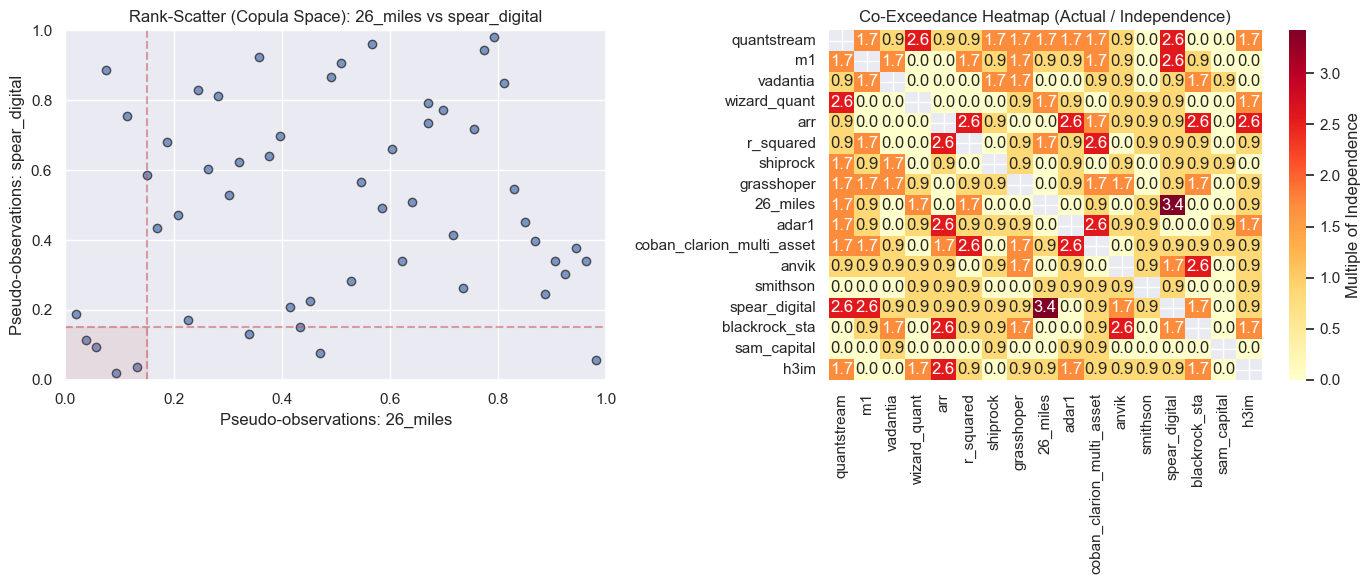

,Fund Pair,Linear Correlation,Left-Tail Correlation,Lambda_L
0,26_miles - spear_digital,0.064516,-0.220790,0.512821
1,arr - h3im,0.205381,-0.376679,0.384615
2,m1 - spear_digital,0.212202,-0.189442,0.384615
3,adar1 - coban_clarion_multi_asset,0.071015,-0.775864,0.384615
4,anvik - blackrock_sta,0.213526,-0.586212,0.384615
5,quantstream - spear_digital,0.203500,-0.001517,0.384615
6,r_squared - coban_clarion_multi_asset,0.096261,-0.557413,0.384615
7,arr - r_squared,0.165921,-0.234672,0.384615
8,arr - blackrock_sta,0.096756,-0.340673,0.384615
9,arr - adar1,0.096920,-0.396336,0.384615


In [69]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.optimize import minimize

# 1. DEPENDENCIES & DATA PREPARATION
# Ensure we're using the columns corresponding to the funds
funds_cols = [c for c in df.columns if c != 'sp500']

# Transform to empirical uniform margins (pseudo-observations)
# U = Rank(R) / (T + 1)
U = df[funds_cols].rank() / (len(df) + 1)

# 2. QUANTIFY TAIL DEPENDENCE METRICS
q = 0.15

# Empirical Lower Tail Dependence Coefficient (λ_L)
lambda_L_matrix = pd.DataFrame(index=funds_cols, columns=funds_cols, dtype=float)
for f1 in funds_cols:
    for f2 in funds_cols:
        if f1 == f2:
            lambda_L_matrix.loc[f1, f2] = 1.0
        else:
            joint_prob = ((U[f1] <= q) & (U[f2] <= q)).mean()
            lambda_L_matrix.loc[f1, f2] = joint_prob / q

# Pearson and Spearman correlation matrices
corr_pearson = df[funds_cols].corr(method='pearson')
corr_spearman = df[funds_cols].corr(method='spearman')

# Left-Tail Correlation Matrix
left_tail_corr = pd.DataFrame(index=funds_cols, columns=funds_cols, dtype=float)
for f1 in funds_cols:
    for f2 in funds_cols:
        if f1 == f2:
            left_tail_corr.loc[f1, f2] = 1.0
        else:
            mask = (U[f1] <= q) | (U[f2] <= q)
            if mask.sum() > 1:
                left_tail_corr.loc[f1, f2] = df.loc[mask, f1].corr(df.loc[mask, f2])
            else:
                left_tail_corr.loc[f1, f2] = np.nan

# 3. COPULA FITTING
# Fit a Student-t Copula to extract the degrees of freedom
def t_copula_nll(nu, u, R):
    try:
        nu = nu[0]
        if nu <= 2.01 or nu > 100:
            return 1e10
        d = u.shape[1]
        x = stats.t.ppf(u, df=nu)
        invR = np.linalg.inv(R)
        detR = np.linalg.det(R)
        q_form = np.sum(np.dot(x, invR) * x, axis=1)
        
        log_joint = (math.lgamma((nu + d)/2) - math.lgamma(nu/2) 
                     - (d/2)*np.log(nu*np.pi) - 0.5*np.log(detR) 
                     - ((nu + d)/2)*np.log(1 + q_form/nu))
                     
        log_margins = (math.lgamma((nu + 1)/2) - math.lgamma(nu/2)
                       - 0.5*np.log(nu*np.pi) 
                       - ((nu + 1)/2)*np.log(1 + x**2/nu))
                       
        ll = np.sum(log_joint - np.sum(log_margins, axis=1))
        if np.isnan(ll) or np.isinf(ll):
            return 1e10
        return -ll
    except Exception:
        return 1e10

R_hat = np.corrcoef(stats.norm.ppf(np.clip(U.values, 0.001, 0.999)), rowvar=False)
res_t = minimize(t_copula_nll, x0=[10.0], args=(np.clip(U.values, 0.01, 0.99), R_hat), bounds=[(2.1, 100)])
print(f"Fitted Student-t Copula Degrees of Freedom: {res_t.x[0]:.2f}")

# Fit a Clayton Copula (Optional but preferred)
def clayton_copula_nll(theta, u):
    try:
        theta = theta[0]
        if theta <= 0.01:
            return 1e10
        d = u.shape[1]
        
        term1 = np.sum(u**(-theta), axis=1) - d + 1
        if np.any(term1 <= 0):
            return 1e10
            
        log_term1 = -(1/theta + d) * np.log(term1)
        log_term2 = -(theta + 1) * np.sum(np.log(u), axis=1)
        
        j = np.arange(d)
        log_term3 = np.sum(np.log(1 + j*theta))
        
        ll = np.sum(log_term1 + log_term2 + log_term3)
        if np.isnan(ll) or np.isinf(ll):
            return 1e10
        return -ll
    except Exception:
        return 1e10

res_clayton = minimize(clayton_copula_nll, x0=[1.0], args=(np.clip(U.values, 0.01, 0.99),), bounds=[(0.01, 20)])
print(f"Fitted Clayton Copula Theta: {res_clayton.x[0]:.2f}")

# 4. VISUALIZATION
# Find critical pair
for f in lambda_L_matrix.columns:
    lambda_L_matrix.loc[f, f] = np.nan
crit_pair = lambda_L_matrix.stack().idxmax()
f1, f2 = crit_pair

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# a) Rank-Scatter Plot
axes[0].scatter(U[f1], U[f2], alpha=0.7, edgecolors='k')
axes[0].axvline(q, color='r', linestyle='--', alpha=0.5)
axes[0].axhline(q, color='r', linestyle='--', alpha=0.5)
axes[0].fill_between([0, q], 0, q, color='r', alpha=0.1)
axes[0].set_title(f"Rank-Scatter (Copula Space): {f1} vs {f2}")
axes[0].set_xlabel(f"Pseudo-observations: {f1}")
axes[0].set_ylabel(f"Pseudo-observations: {f2}")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# b) Co-Exceedance Heatmap
co_exceedance = pd.DataFrame(index=funds_cols, columns=funds_cols, dtype=float)
for col1 in funds_cols:
    for col2 in funds_cols:
        if col1 == col2:
            co_exceedance.loc[col1, col2] = np.nan
        else:
            joint_prob = ((U[col1] <= q) & (U[col2] <= q)).mean()
            indep_prob = q * q
            co_exceedance.loc[col1, col2] = joint_prob / indep_prob

sns.heatmap(co_exceedance, annot=True, cmap="YlOrRd", ax=axes[1], fmt=".1f", cbar_kws={'label': 'Multiple of Independence'})
axes[1].set_title("Co-Exceedance Heatmap (Actual / Independence)")
plt.tight_layout()
plt.show()

# c) Comparative DataFrame/Table
pairs = []
for i in range(len(funds_cols)):
    for j in range(i+1, len(funds_cols)):
        col1 = funds_cols[i]
        col2 = funds_cols[j]
        pairs.append({
            'Fund Pair': f"{col1} - {col2}",
            'Linear Correlation': corr_pearson.loc[col1, col2],
            'Left-Tail Correlation': left_tail_corr.loc[col1, col2],
            'Lambda_L': lambda_L_matrix.loc[col1, col2]
        })

comp_df = pd.DataFrame(pairs).sort_values(by='Lambda_L', ascending=False).reset_index(drop=True)
display(comp_df.head(15))


,Annualized Mean,Annualized Std,Proxy Sharpe
h3im,0.258222,0.020612,12.527744
smithson,0.394173,0.065980,5.974107
anvik,0.440712,0.077403,5.693714
coban_clarion_multi_asset,0.318600,0.079344,4.015419
m1,0.171240,0.054253,3.156331
26_miles,0.227036,0.073559,3.086469
grasshoper,0.246729,0.085271,2.893475
sam_capital,0.400897,0.144098,2.782104
blackrock_sta,0.139930,0.056084,2.495019
quantstream,0.199866,0.084560,2.363604


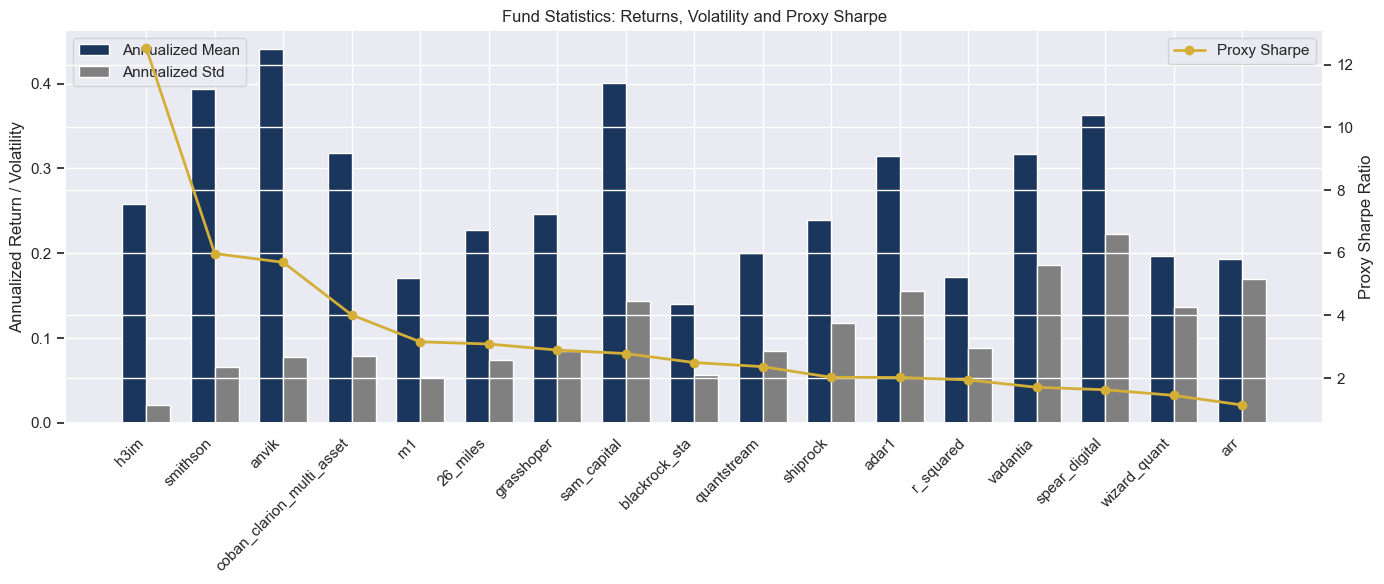

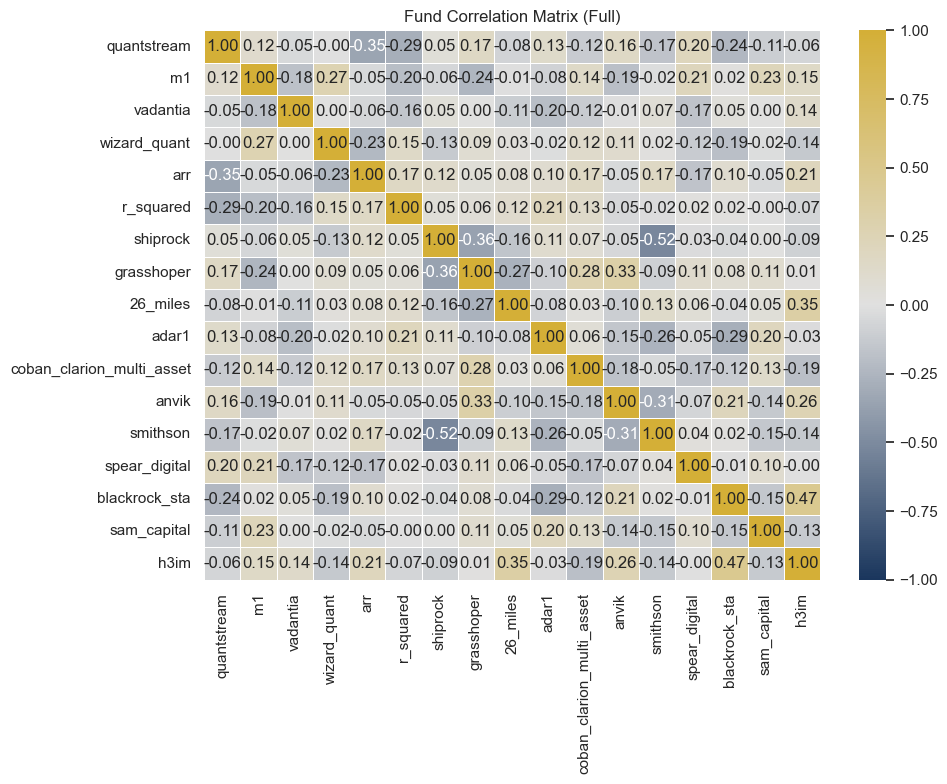

In [70]:
# Compute annualized metrics for individual funds
df_funds_full = df_full[funds].dropna(how='all')
df_funds = df[funds].dropna(how='all')

stats_df = pd.DataFrame(
    {
        "Annualized Mean": df_funds_full.mean() * 12,
        "Annualized Std": df_funds_full.std() * np.sqrt(12),
    }
)

stats_df["Proxy Sharpe"] = stats_df["Annualized Mean"] / stats_df["Annualized Std"]
stats_df_sorted = stats_df.sort_values(by="Proxy Sharpe", ascending=False)
display(stats_df_sorted)

# Plot returns and vol together for each fund with Proxy Sharpe on a line
fig, ax1 = plt.subplots(figsize=(14, 6))

x = np.arange(len(stats_df_sorted))
width = 0.35

ax1.bar(x - width/2, stats_df_sorted["Annualized Mean"], width, label='Annualized Mean', color='#1A365D')
ax1.bar(x + width/2, stats_df_sorted["Annualized Std"], width, label='Annualized Std', color='gray')

ax1.set_ylabel('Annualized Return / Volatility')
ax1.set_title('Fund Statistics: Returns, Volatility and Proxy Sharpe')
ax1.set_xticks(x)
ax1.set_xticklabels(stats_df_sorted.index, rotation=45, ha='right')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(x, stats_df_sorted["Proxy Sharpe"], color='#D4AF37', marker='o', linewidth=2, label='Proxy Sharpe')
ax2.set_ylabel('Proxy Sharpe Ratio')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Heatmap of correlation between the funds (lower triangle only)
corr_matrix = df_funds_full.corr()
plt.figure(figsize=(10, 8))
import matplotlib.colors as mcolors
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom", ["#1A365D", "#E0E0E0", "#D4AF37"])
sns.heatmap(corr_matrix, annot=True, cmap=custom_cmap, vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Fund Correlation Matrix (Full)')
plt.tight_layout()
plt.show()


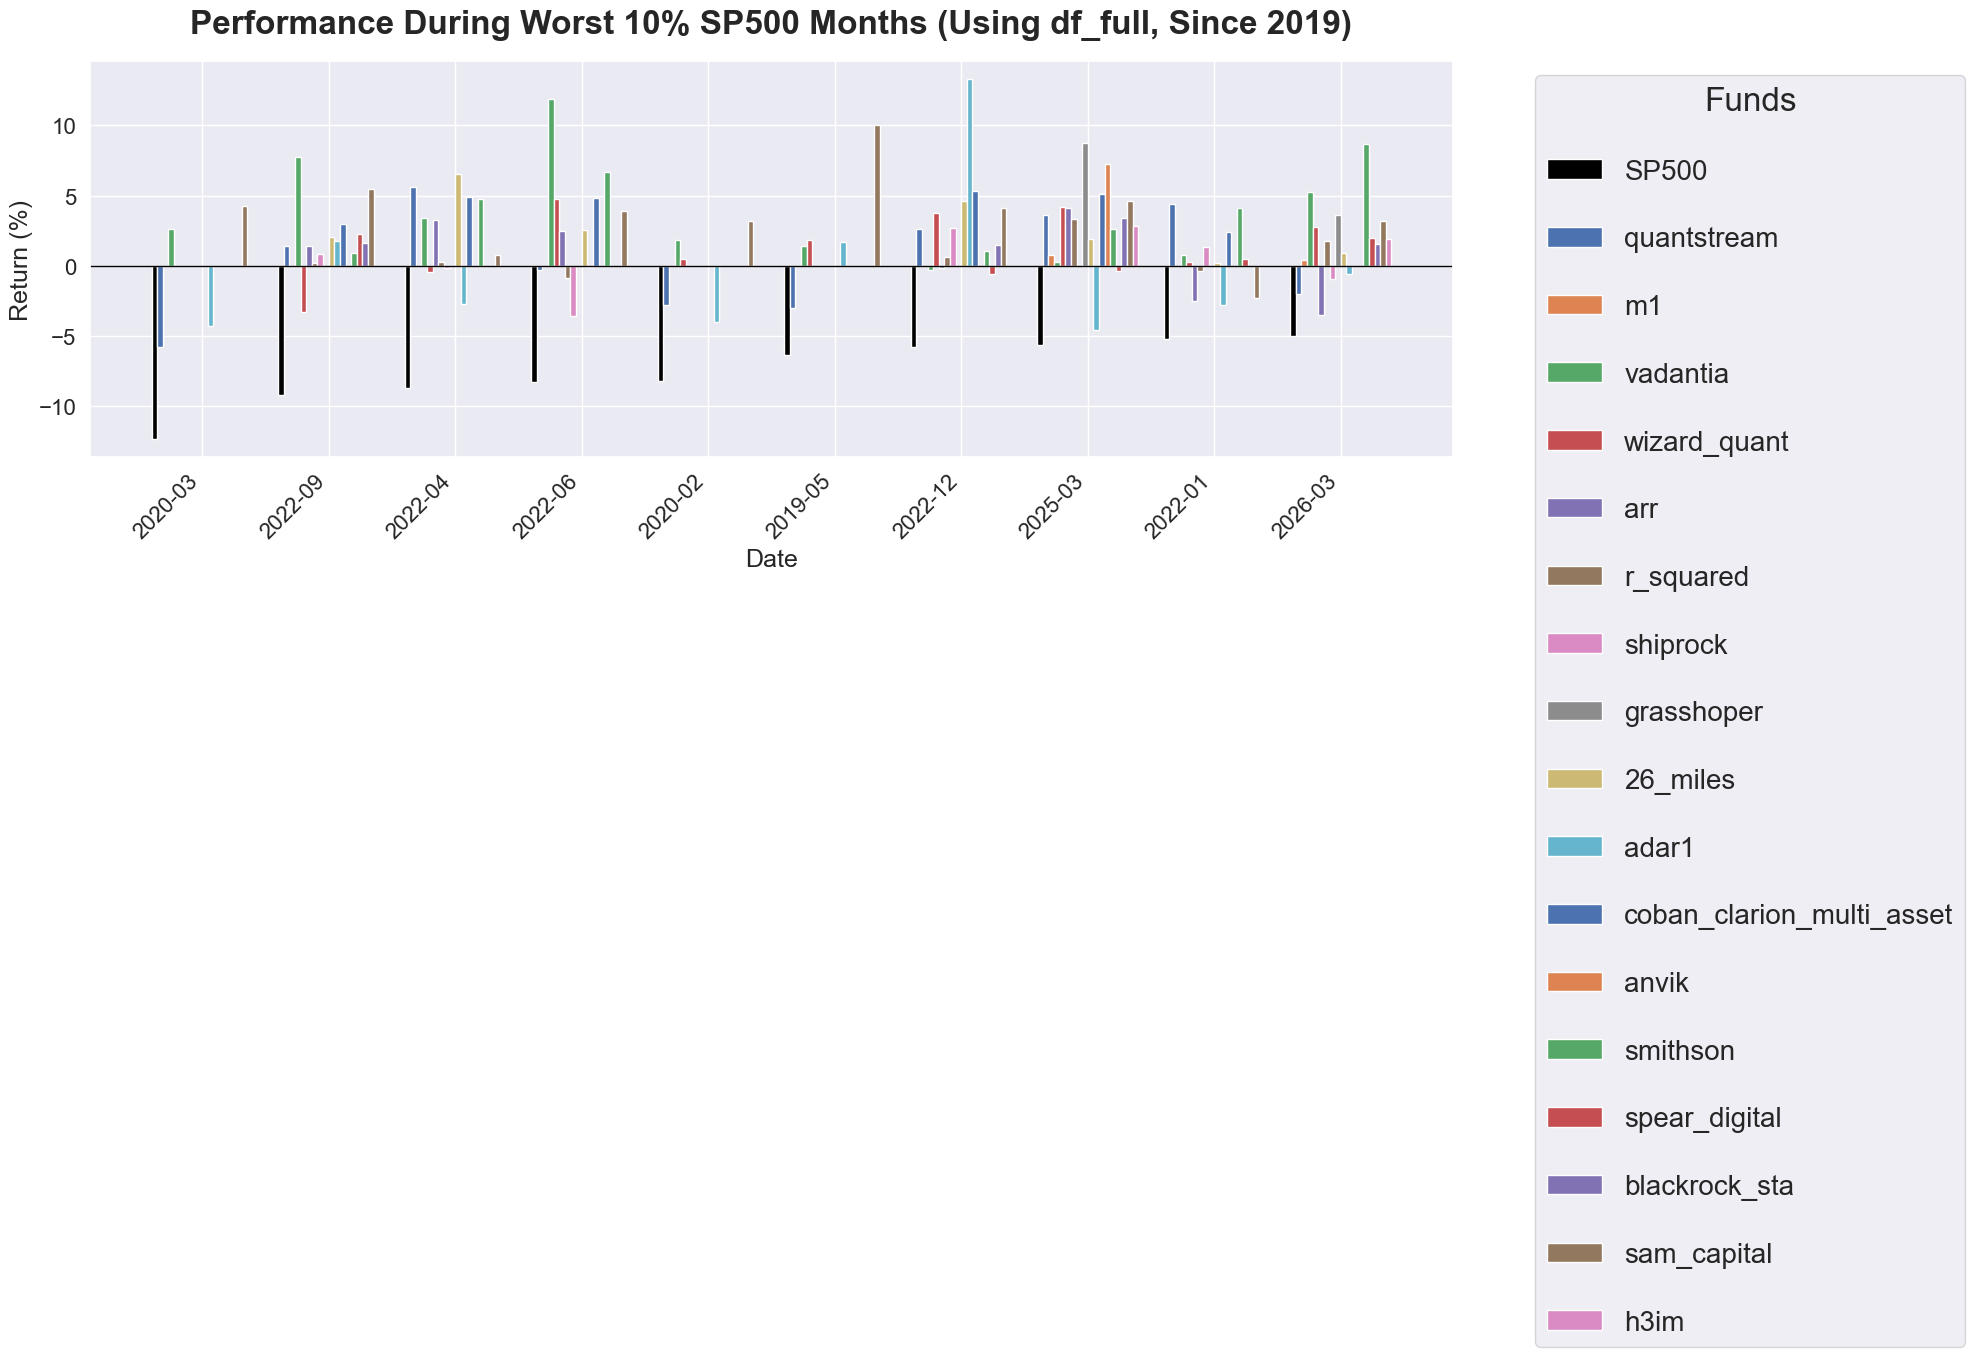

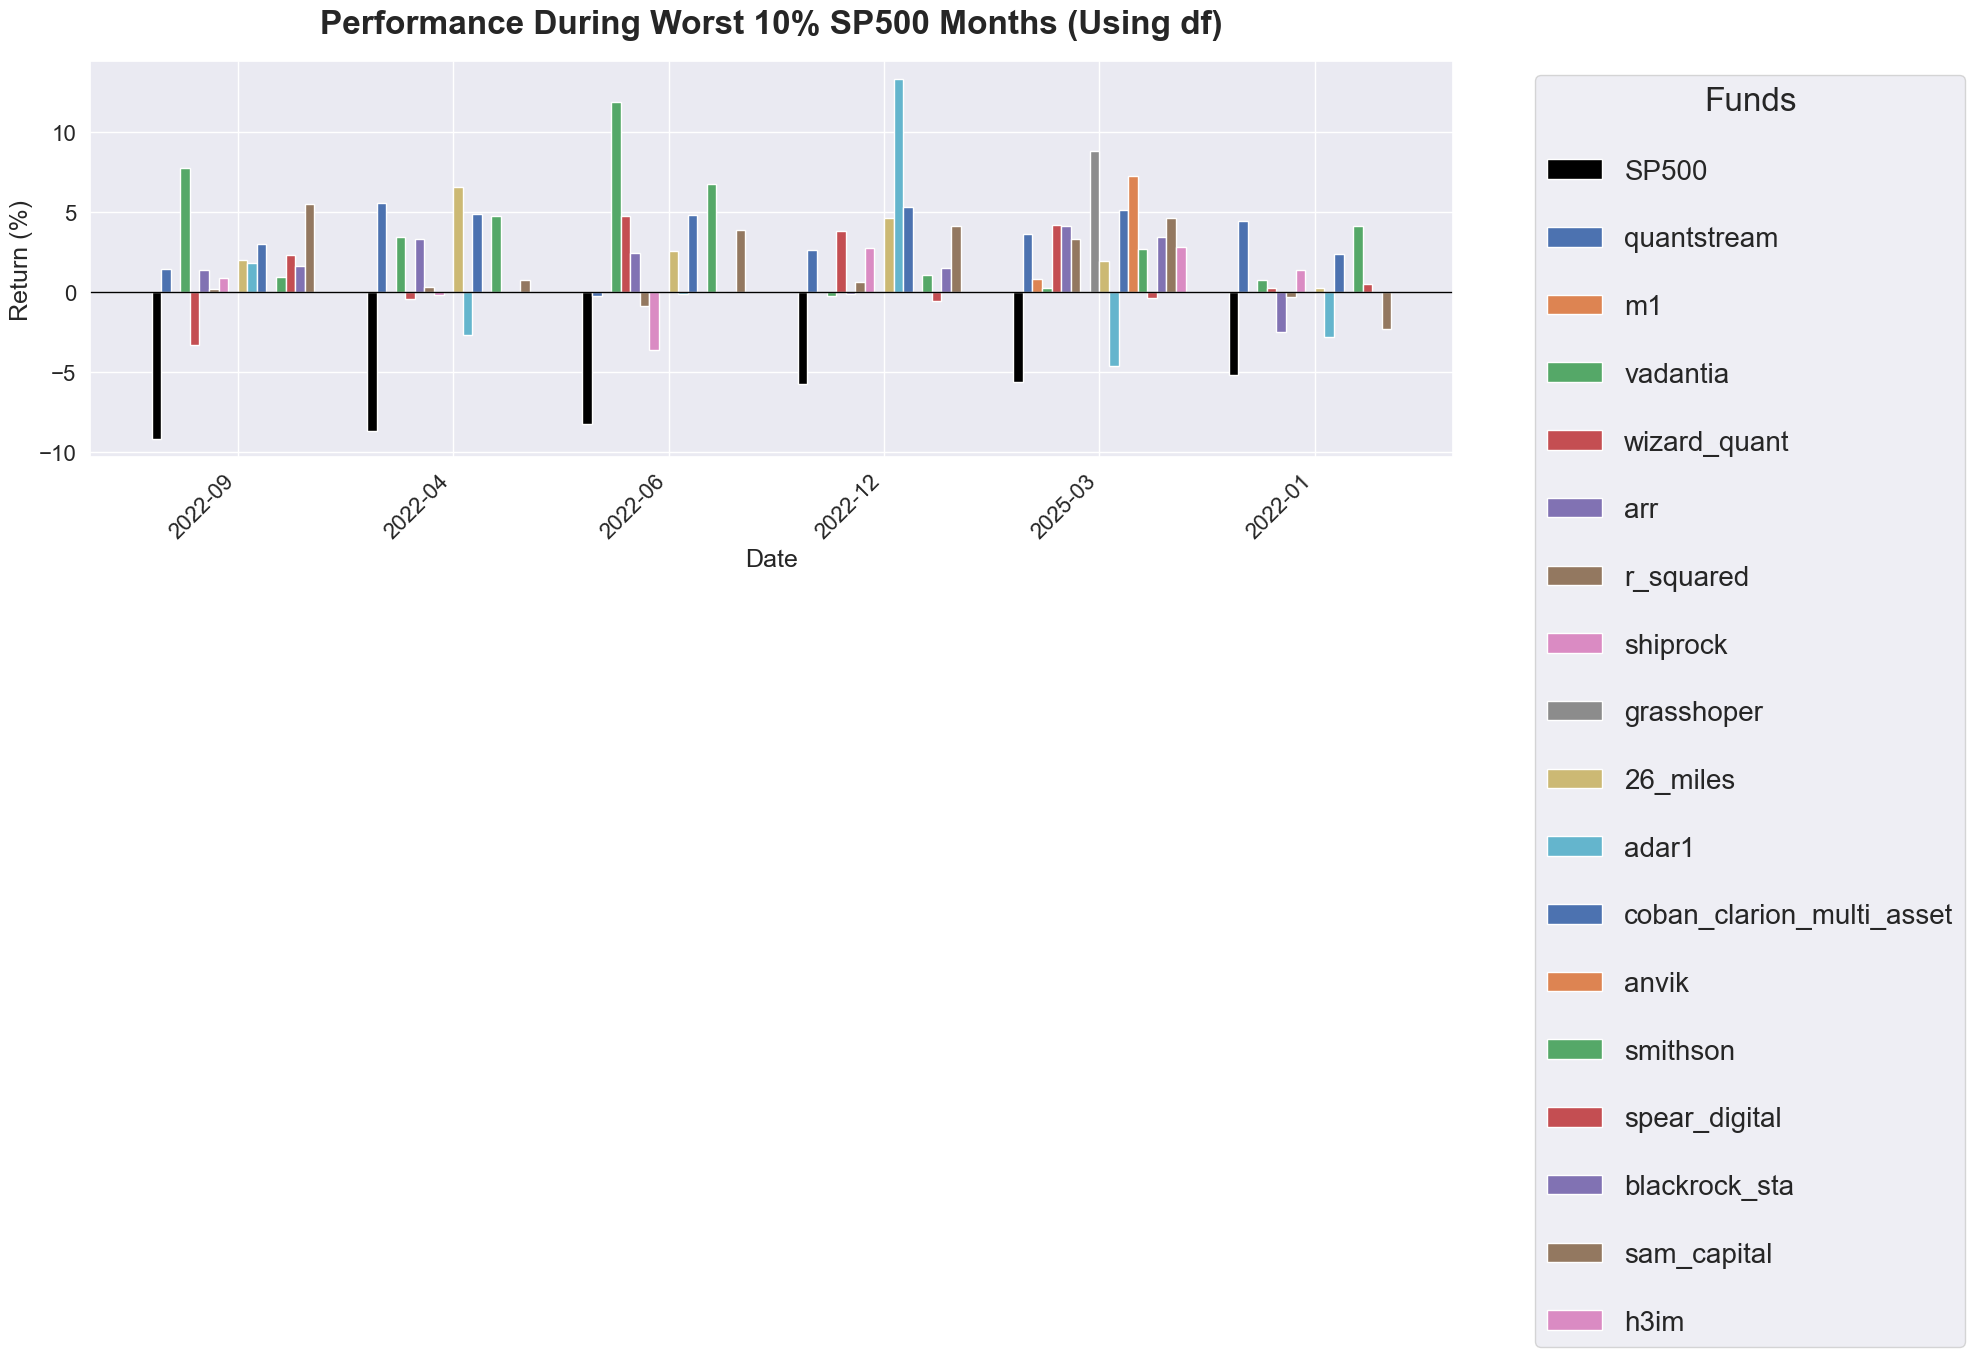

In [71]:
# --- Worst 10% SP500 Months Analysis (All Funds) ---
import pandas as pd

def plot_worst_sp500_months_interactive(data_df, title_suffix="", start_date=None, save_path=None, figsize=(20, 10), pad=20):
    df_plot = data_df.copy()
    if start_date:
        df_plot = df_plot[df_plot.index >= pd.to_datetime(start_date)]
        
    # Find worst 10% SP500 months
    q10_sp500 = df_plot['sp500'].quantile(0.10)
    worst_months = df_plot[df_plot['sp500'] <= q10_sp500].copy()
    
    # Sort by SP500 returns ascending
    worst_months = worst_months.sort_values(by='sp500', ascending=True)
    
    # Prepare data for plotting
    cols_to_plot = ['sp500'] + [c for c in df_plot.columns if c != 'sp500']
    
    plot_data = worst_months[cols_to_plot].copy()
    plot_data.index = plot_data.index.strftime('%Y-%m') # Format dates for x-axis
    plot_data = plot_data * 100 # Convert to percentage
    
    # Create grouped bar plot with matplotlib
    import matplotlib.pyplot as plt
    import numpy as np
    
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(plot_data))
    num_cols = len(cols_to_plot)
    width = 0.8 / num_cols
    
    # Plot SP500 first (in black)
    ax.bar(x - width * (num_cols / 2 - 0.5), plot_data['sp500'], width, label='SP500', color='black')
    
    # Plot other funds
    for i, col in enumerate([c for c in cols_to_plot if c != 'sp500']):
        ax.bar(x - width * (num_cols / 2 - 0.5) + (i + 1) * width, plot_data[col], width, label=col)
        
    ax.set_title(f'Performance During Worst 10% SP500 Months {title_suffix}', fontsize=24, fontweight='bold', pad=pad)
    ax.set_xlabel('Date', fontsize=18)
    ax.set_ylabel('Return (%)', fontsize=18)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_data.index, rotation=45, ha='right', fontsize=16)
    ax.legend(title='Funds', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20, title_fontsize=24, labelspacing=1.5, markerscale=2)
    ax.axhline(0, color='black', linewidth=1)
    
    plt.tight_layout()
    
    if save_path:
        import os
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight')
        
    plt.show()

# Plot using df_full starting from 2019
plot_worst_sp500_months_interactive(df_full, "(Using df_full, Since 2019)", start_date="2019-01-01")

# Plot using df
plot_worst_sp500_months_interactive(df, "(Using df)")

def plot_yearly_returns_interactive(data_df, title_suffix="", start_date=None, save_path=None, figsize=(20, 10), pad=20):
    df_plot = data_df.copy()
    if start_date:
        df_plot = df_plot[df_plot.index >= pd.to_datetime(start_date)]
        
    # Calculate yearly returns
    yearly_returns = (1 + df_plot).groupby(df_plot.index.year).prod() - 1
    
    # Prepare data for plotting
    cols_to_plot = ['sp500'] + [c for c in df_plot.columns if c != 'sp500']
    
    plot_data = yearly_returns[cols_to_plot].copy()
    plot_data = plot_data * 100 # Convert to percentage
    
    import matplotlib.pyplot as plt
    import numpy as np
    
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(plot_data))
    num_cols = len(cols_to_plot)
    width = 0.8 / num_cols
    
    # Plot SP500 first (in black)
    ax.bar(x - width * (num_cols / 2 - 0.5), plot_data['sp500'], width, label='SP500', color='black')
    
    # Plot other funds
    for i, col in enumerate([c for c in cols_to_plot if c != 'sp500']):
        ax.bar(x - width * (num_cols / 2 - 0.5) + (i + 1) * width, plot_data[col], width, label=col)
        
    ax.set_title(f'Yearly Returns {title_suffix}', fontsize=24, fontweight='bold', pad=pad)
    ax.set_xlabel('Year', fontsize=18)
    ax.set_ylabel('Return (%)', fontsize=18)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_data.index, rotation=45, ha='right', fontsize=16)
    ax.legend(title='Funds', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20, title_fontsize=24, labelspacing=1.5, markerscale=2)
    ax.axhline(0, color='black', linewidth=1)
    
    plt.tight_layout()
    
    if save_path:
        import os
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight')
        
    plt.show()

## Portfolios Construction

We construct four portfolios based on initial allocations (in millions):
1. **Monthly Equal Weight (Baseline)**: simple equal weighting of all funds rebalanced monthly.
2. **Drifting Initial Allocation**: initial capital is invested, weights drift without rebalancing.
3. **Monthly Rebalanced Initial Allocation**: weights are set to initial allocation proportions, rebalanced monthly.
4. **6-Month Rebalanced Initial Allocation**: weights are reset to initial allocation proportions every 6 months.

In [72]:
# Initial capital allocation per fund (in millions)
allocations = {
    'quantstream': 1,
    'm1': 1,
    'vadantia': 1.0,
    # 'enko': 1.0,
    'wizard_quant': 1.0,
    'arr': 1,
    'r_squared': 1.0,
    'shiprock': 1.0,
    'grasshoper': 2.0,
    'smithson':2,
    # 'edge_capital': 1.0
    '26_miles': 1.0,
    # 'adar1':1,
    'h3im': 1,
    # 'sam_capital':1
    # 'coban_clarion_multi_asset': 1,
    # 'coban_pod_1': 1,
    # 'coban_orca': 1
}

s = 0
for k, v in allocations.items():
    s += v

print(f'Initial exposure is {s}M USD')

allocations_s = pd.Series(allocations)
# Align with available funds in df
allocations_s = allocations_s[allocations_s.index.isin(df_funds.columns)]

# 1. Monthly Equal Weight
eq_portfolio_return = df_funds.mean(axis=1)

# Base weights from initial allocation
w_init = allocations_s / allocations_s.sum()

# Dynamic weights normalizing allocation across available funds for each period
active_w_init = df_funds.notna() * allocations_s
active_w_init = active_w_init.div(active_w_init.sum(axis=1), axis=0)
active_w_init = active_w_init.where(df_funds.notna())

# 2. Monthly Rebalanced Initial Allocation
monthly_reb_return = (df_funds * active_w_init).sum(axis=1)

# 3. Drifting Initial Allocation
cum_returns = (1 + df_funds).cumprod()
weights_drift = (cum_returns.shift(1).fillna(1.0) * allocations_s)
weights_drift = weights_drift.where(df_funds.notna())
weights_drift = weights_drift.div(weights_drift.sum(axis=1), axis=0)
drifting_return = (df_funds * weights_drift).sum(axis=1)

# 4. 6-Month Rebalanced Initial Allocation
returns_6m = []
current_weights = active_w_init.iloc[0].copy()
for i in range(len(df_funds)):
    # Ensure we only apply weight to available funds
    cw_active = current_weights.where(df_funds.notna().iloc[i])
    cw_active = cw_active / cw_active.sum()
    
    ret = (df_funds.iloc[i] * cw_active).sum()
    returns_6m.append(ret)
    
    if i + 1 < len(df_funds):
        if (i + 1) % 6 == 0:
            current_weights = active_w_init.iloc[i + 1].copy()
        else:
            # drift the weights
            current_weights = cw_active * (1 + df_funds.iloc[i].fillna(0))
            current_weights = current_weights / current_weights.sum()

returns_6m_series = pd.Series(returns_6m, index=df_funds.index)

# --- Fee Computation ---
APPLY_FEES = True
MANAGEMENT_FEE_ANNUAL = 0.01  # 1% management fee
PERFORMANCE_FEE = 0.20        # 20% performance fee above High Water Mark

def apply_fees(gross_returns, mgt_fee_annual, perf_fee):
    mgt_fee_monthly = mgt_fee_annual / 12.0
    net_returns = []
    hwm = 1.0
    current_nav = 1.0
    
    for ret in gross_returns:
        nav_before_fees = current_nav * (1 + ret)
        nav_after_mgt = nav_before_fees * (1 - mgt_fee_monthly)
        
        if nav_after_mgt > hwm:
            perf_fee_amount = (nav_after_mgt - hwm) * perf_fee
            nav_after_all_fees = nav_after_mgt - perf_fee_amount
            hwm = nav_after_all_fees
        else:
            nav_after_all_fees = nav_after_mgt
            
        net_ret = (nav_after_all_fees / current_nav) - 1
        net_returns.append(net_ret)
        current_nav = nav_after_all_fees
        
    return pd.Series(net_returns, index=gross_returns.index)

if APPLY_FEES:
    eq_portfolio_return = apply_fees(eq_portfolio_return, MANAGEMENT_FEE_ANNUAL, PERFORMANCE_FEE)
    drifting_return = apply_fees(drifting_return, MANAGEMENT_FEE_ANNUAL, PERFORMANCE_FEE)
    monthly_reb_return = apply_fees(monthly_reb_return, MANAGEMENT_FEE_ANNUAL, PERFORMANCE_FEE)
    returns_6m_series = apply_fees(returns_6m_series, MANAGEMENT_FEE_ANNUAL, PERFORMANCE_FEE)
# -----------------------

show_all_portfolios = False

# Combine all portfolios
all_portfolios_df = pd.DataFrame({
    'Monthly Equal Weight': eq_portfolio_return,
    'Drifting Initial Alloc': drifting_return,
    'Monthly Reb Initial Alloc': monthly_reb_return,
    '6-Month Reb Initial Alloc': returns_6m_series
})

all_portfolios_df.dropna(inplace=True)



Initial exposure is 13.0M USD


In [73]:
import pandas as pd

# Analysis of fees for 6-Month Reb Initial Alloc
mgt_fee_annual = 0.01
perf_fee = 0.20
gross_returns = returns_6m_series

mgt_fee_monthly = mgt_fee_annual / 12.0
fees_list = []
hwm = 1.0
current_nav = 1.0

for date, ret in gross_returns.items():
    nav_before_fees = current_nav * (1 + ret)
    mgt_fee_amount = nav_before_fees * mgt_fee_monthly
    nav_after_mgt = nav_before_fees - mgt_fee_amount
    
    if nav_after_mgt > hwm:
        perf_fee_amount = (nav_after_mgt - hwm) * perf_fee
        nav_after_all_fees = nav_after_mgt - perf_fee_amount
        hwm = nav_after_all_fees
    else:
        perf_fee_amount = 0
        nav_after_all_fees = nav_after_mgt
        
    fees_list.append({
        'Date': date,
        'Mgt_Fee_USD': mgt_fee_amount * 1_000_000,
        'Perf_Fee_USD': perf_fee_amount * 1_000_000,
        'Total_Fee_USD': (mgt_fee_amount + perf_fee_amount) * 1_000_000,
        'NAV_after_fees': nav_after_all_fees
    })
    current_nav = nav_after_all_fees

fees_df = pd.DataFrame(fees_list)
fees_df.set_index('Date', inplace=True)
fees_df['Year'] = fees_df.index.year

yearly_summary = []
current_capital = 1_000_000

for year, group in fees_df.groupby('Year'):
    start_capital = current_capital
    mgt_fee = group['Mgt_Fee_USD'].sum()
    perf_fee_val = group['Perf_Fee_USD'].sum()
    total_fee = group['Total_Fee_USD'].sum()
    
    # Capital at the end of the year
    end_nav = group['NAV_after_fees'].iloc[-1]
    
    yearly_summary.append({
        'Year': year,
        'Starting Capital (USD)': start_capital,
        'Mgt Fee (USD)': mgt_fee,
        'Perf Fee (USD)': perf_fee_val,
        'Total Fee (USD)': total_fee,
        'Total Fee (%)': (total_fee / start_capital) * 100
    })
    
    # Update current capital for next year
    current_capital = end_nav * 1_000_000

yearly_summary_df = pd.DataFrame(yearly_summary)
yearly_summary_df.set_index('Year', inplace=True)

from IPython.display import HTML, display
display(HTML("<h3 style='color: firebrick;'>Annual Fee Analysis (Based on 1M USD Initial Allocation)</h3>"))
display(yearly_summary_df.round(2))


,Starting Capital (USD),Mgt Fee (USD),Perf Fee (USD),Total Fee (USD),Total Fee (%)
Year,,,,,
2022,1000000.00,11308.63,52651.44,63960.08,6.40
2023,1210605.78,13143.93,48299.62,61443.54,5.08
2024,1403804.24,15353.24,56295.61,71648.85,5.10
2025,1628986.67,17675.99,61329.65,79005.63,4.85
2026,1874305.26,6412.89,17197.27,23610.15,1.26


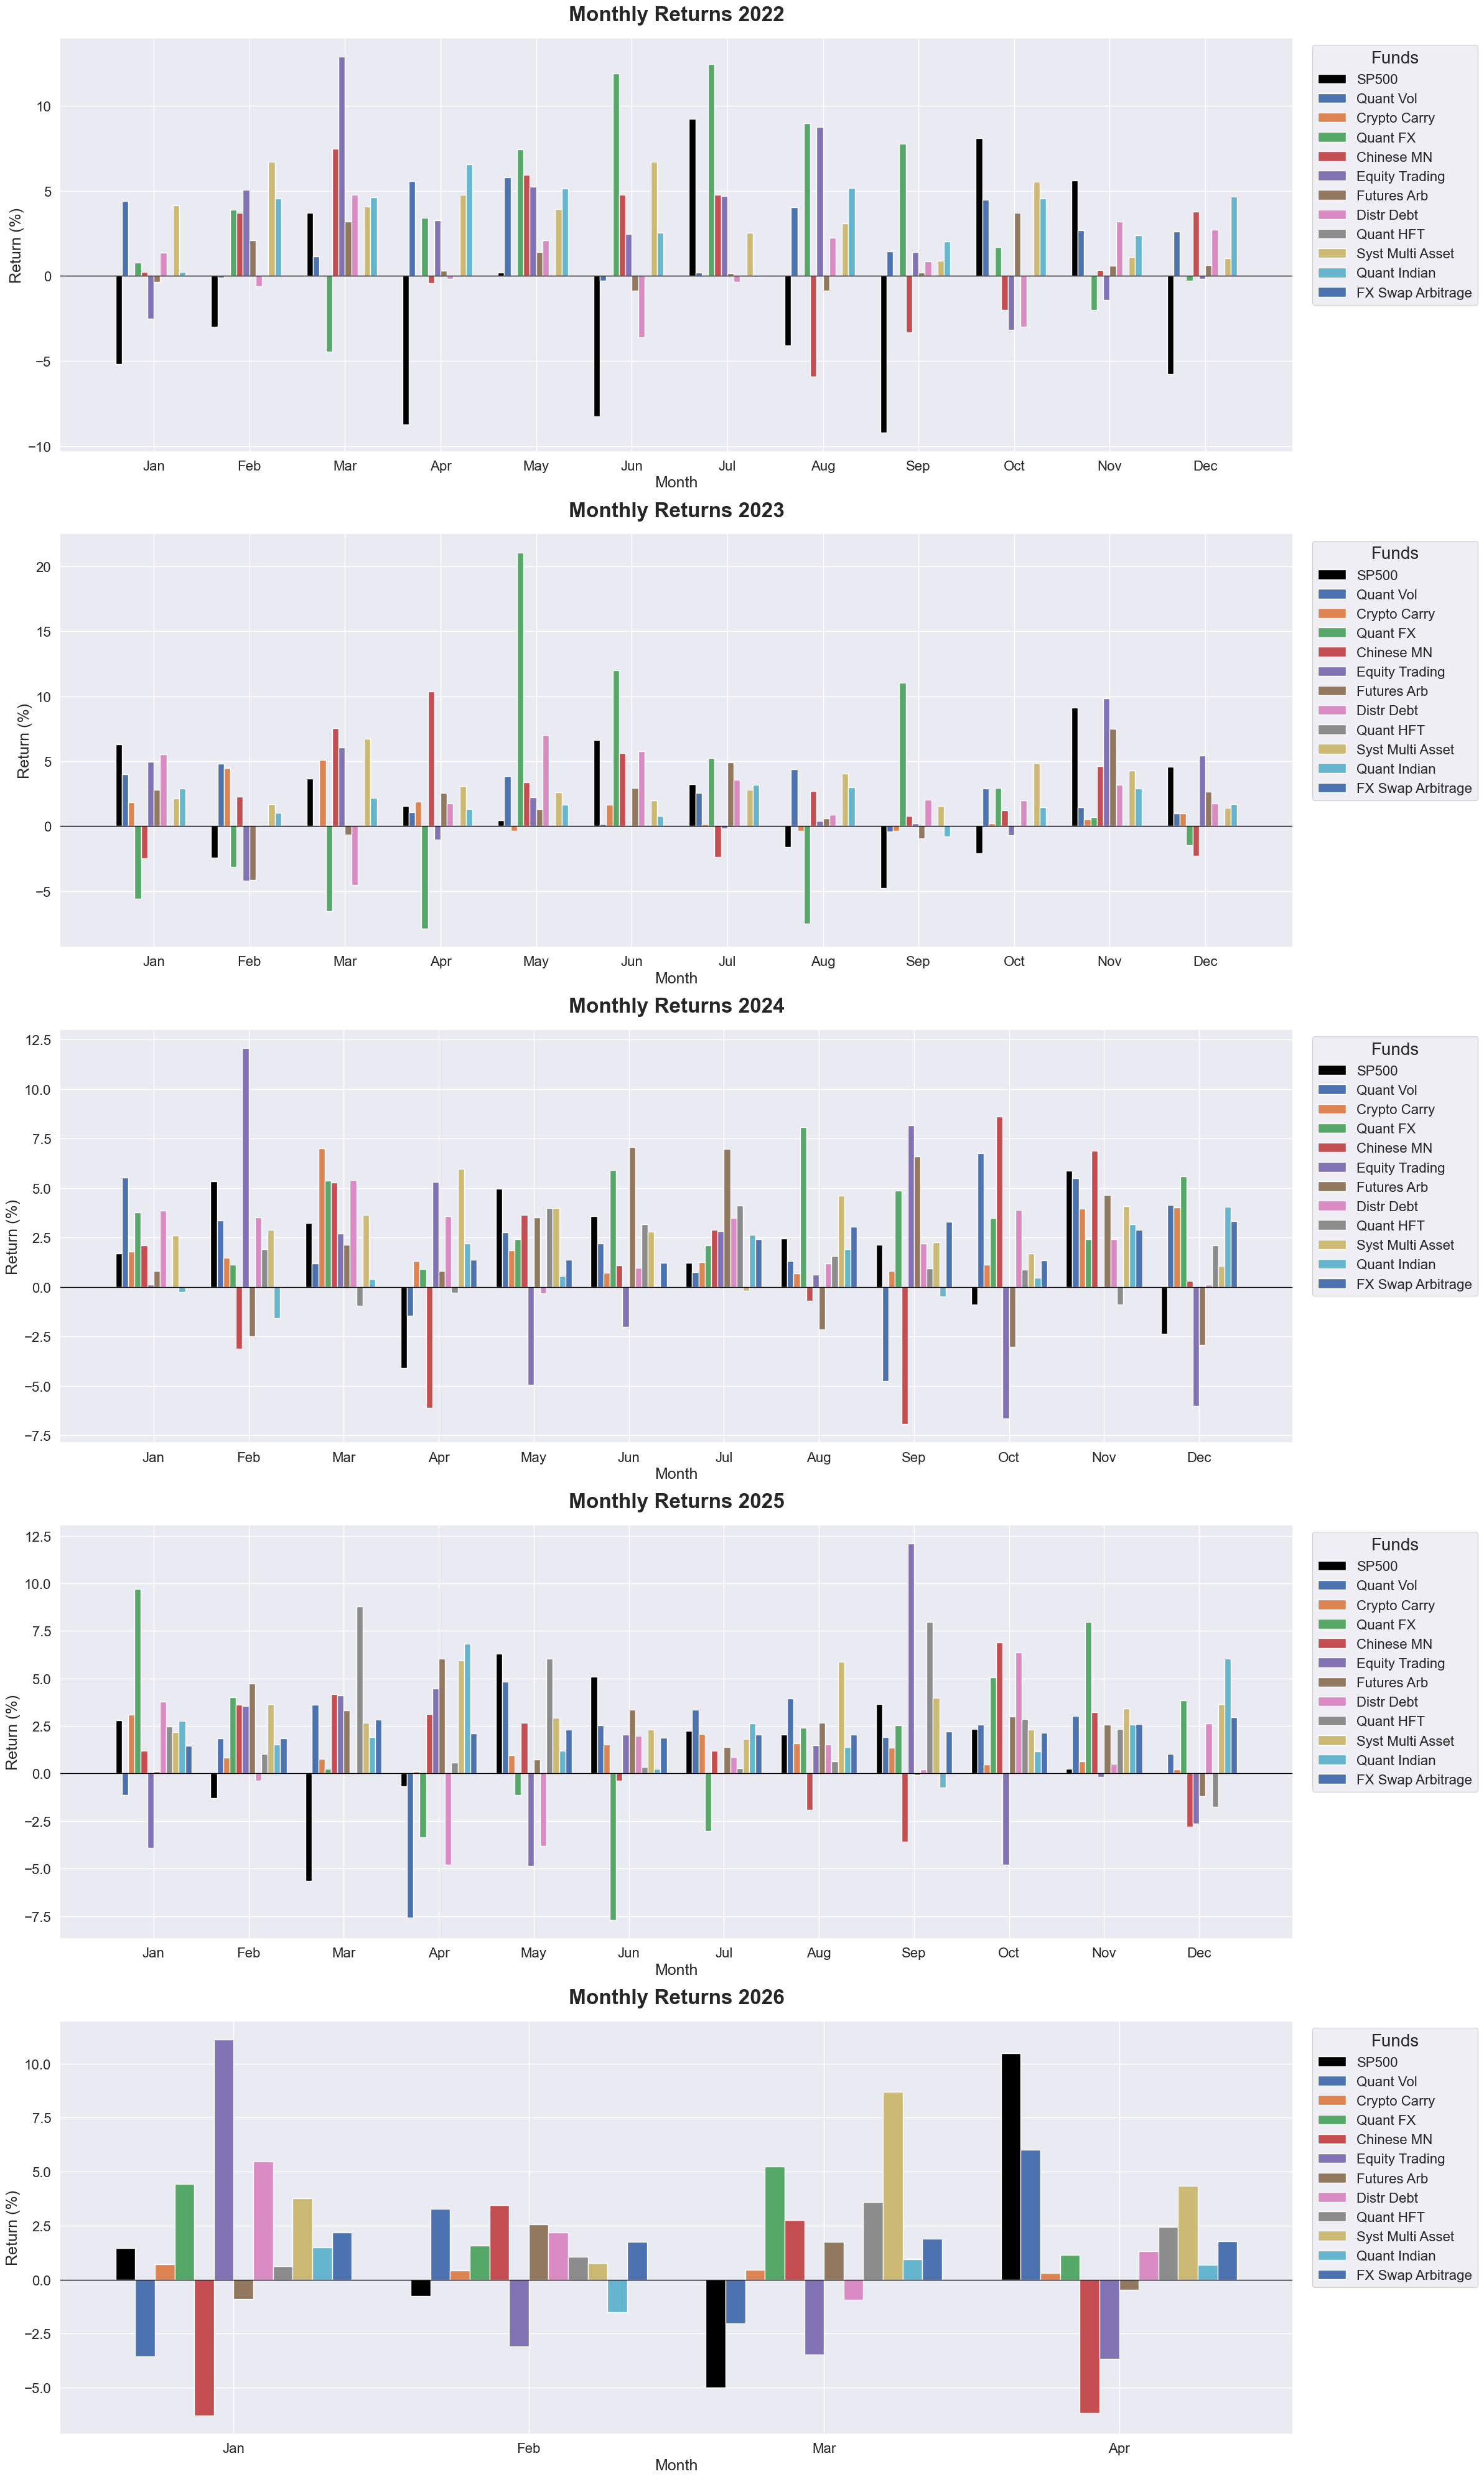

In [74]:
import os

def plot_monthly_returns_separate_years(data_df, save_path=None):
    df_plot = data_df.copy()
    
    # Only keep funds that are in allocations + sp500
    funds_in_portfolio = list(allocations.keys())
    cols_to_plot = ['sp500'] + [c for c in funds_in_portfolio if c in df_plot.columns]
    
    years = df_plot.index.year.unique()
    n_years = len(years)
    
    fig, axes = plt.subplots(nrows=n_years, ncols=1, figsize=(24, 8 * n_years))
    if n_years == 1:
        axes = [axes]
        
    for ax, year in zip(axes, years):
        df_year = df_plot[df_plot.index.year == year]
        plot_data = df_year[cols_to_plot] * 100
        
        x = np.arange(len(plot_data))
        num_cols = len(cols_to_plot)
        width = 0.8 / num_cols
        
        ax.bar(x - width * (num_cols / 2 - 0.5), plot_data['sp500'], width, label='SP500', color='black')
        
        for i, col in enumerate([c for c in cols_to_plot if c != 'sp500']):
            ax.bar(x - width * (num_cols / 2 - 0.5) + (i + 1) * width, plot_data[col], width, label=fund_short_names.get(col, col))
            
        ax.set_title(f'Monthly Returns {year}', fontsize=24, fontweight='bold', pad=20)
        ax.set_xlabel('Month', fontsize=18)
        ax.set_ylabel('Return (%)', fontsize=18)
        ax.set_xticks(x)
        ax.set_xticklabels([d.strftime('%b') for d in df_year.index], fontsize=16)
        ax.axhline(0, color='black', linewidth=1)
        ax.tick_params(axis='y', labelsize=16)
        
        ax.legend(title='Funds', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=16, title_fontsize=20, markerscale=2)

    plt.tight_layout()
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight')
        
    plt.show()

# Generate and save the plot
plot_monthly_returns_separate_years(df, save_path='./report/monthly_returns_bar_plot.png')

In [75]:
# --- Missing Data Analysis (Selected Funds) ---
import pandas as pd
from IPython.display import display

live_years = all_portfolios_df.index.year.unique()
selected_funds = allocations_s.index

missing_summary = []
for year in live_years:
    year_data = df_funds_full.loc[df_funds_full.index.year == year, selected_funds]
    missing_funds = year_data.isna().any(axis=0)
    num_missing = missing_funds.sum()
    missing_names = ', '.join(missing_funds[missing_funds].index) if num_missing > 0 else 'None'
    
    missing_summary.append({
        'Year': year,
        'Total Selected Funds': len(selected_funds),
        'Funds with Missing Data': num_missing,
        'Missing Fund Names': missing_names
    })

missing_df = pd.DataFrame(missing_summary).set_index('Year')
print('\nMissing Data Summary for Selected Funds (per live year):')
display(missing_df)



Missing Data Summary for Selected Funds (per live year):


,Total Selected Funds,Funds with Missing Data,Missing Fund Names
Year,,,
2022,11,3,"m1, grasshoper, h3im"
2023,11,2,"grasshoper, h3im"
2024,11,2,"grasshoper, h3im"
2025,11,0,None
2026,11,10,"quantstream, m1, vadantia, wizard_quant, arr, ..."


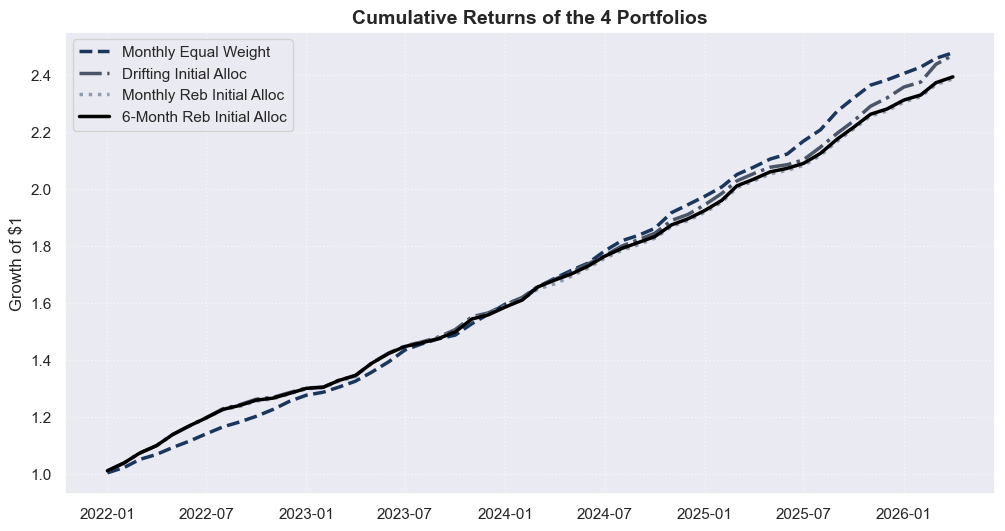

,6-Month Reb Initial Alloc
date,
2022-01-01,0.010359
2022-02-01,0.027782
2022-03-01,0.032661
2022-04-01,0.024473
2022-05-01,0.035709


In [76]:
# Plot cumulative returns of the portfolios (ALWAYS SHOW ALL 4)
cum_portfolios = (1 + all_portfolios_df).cumprod()
plt.figure(figsize=(12, 6))

# Custom palette: Dark Blue, Slate, Steel Grey, and Pure Black
colors = {
    '6-Month Reb Initial Alloc': '#000000',   # Pure Black
    'Monthly Equal Weight': '#1A365D',      # Dark Navy Blue
    'Drifting Initial Alloc': '#4A5568',     # Slate / Medium Charcoal
    'Monthly Reb Initial Alloc': '#8C9BAE'   # Steel Grey
}

# Line styles to make overlapping lines immediately clear
linestyles = {
    '6-Month Reb Initial Alloc': '-',
    'Monthly Equal Weight': '--',
    'Drifting Initial Alloc': '-.',
    'Monthly Reb Initial Alloc': ':'
}

for col in cum_portfolios.columns:
    plt.plot(
        cum_portfolios.index, 
        cum_portfolios[col], 
        label=col, 
        linewidth=2.5, 
        color=colors[col],
        linestyle=linestyles[col]
    )

plt.title('Cumulative Returns of the 4 Portfolios', fontsize=14, fontweight='bold')
plt.ylabel('Growth of $1', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

import os
os.makedirs('report', exist_ok=True)
plt.savefig('report/4_strategies_growth.pdf', bbox_inches='tight')
plt.show()


# Set portfolios_df based on the boolean flag to control downstream statistics
if show_all_portfolios:
    portfolios_df = all_portfolios_df
else:
    portfolios_df = all_portfolios_df[['6-Month Reb Initial Alloc']]

portfolios_df.head()

In [77]:
w_init


quantstream     0.076923
m1              0.076923
vadantia        0.076923
wizard_quant    0.076923
arr             0.076923
r_squared       0.076923
shiprock        0.076923
grasshoper      0.153846
smithson        0.153846
26_miles        0.076923
h3im            0.076923
dtype: float64

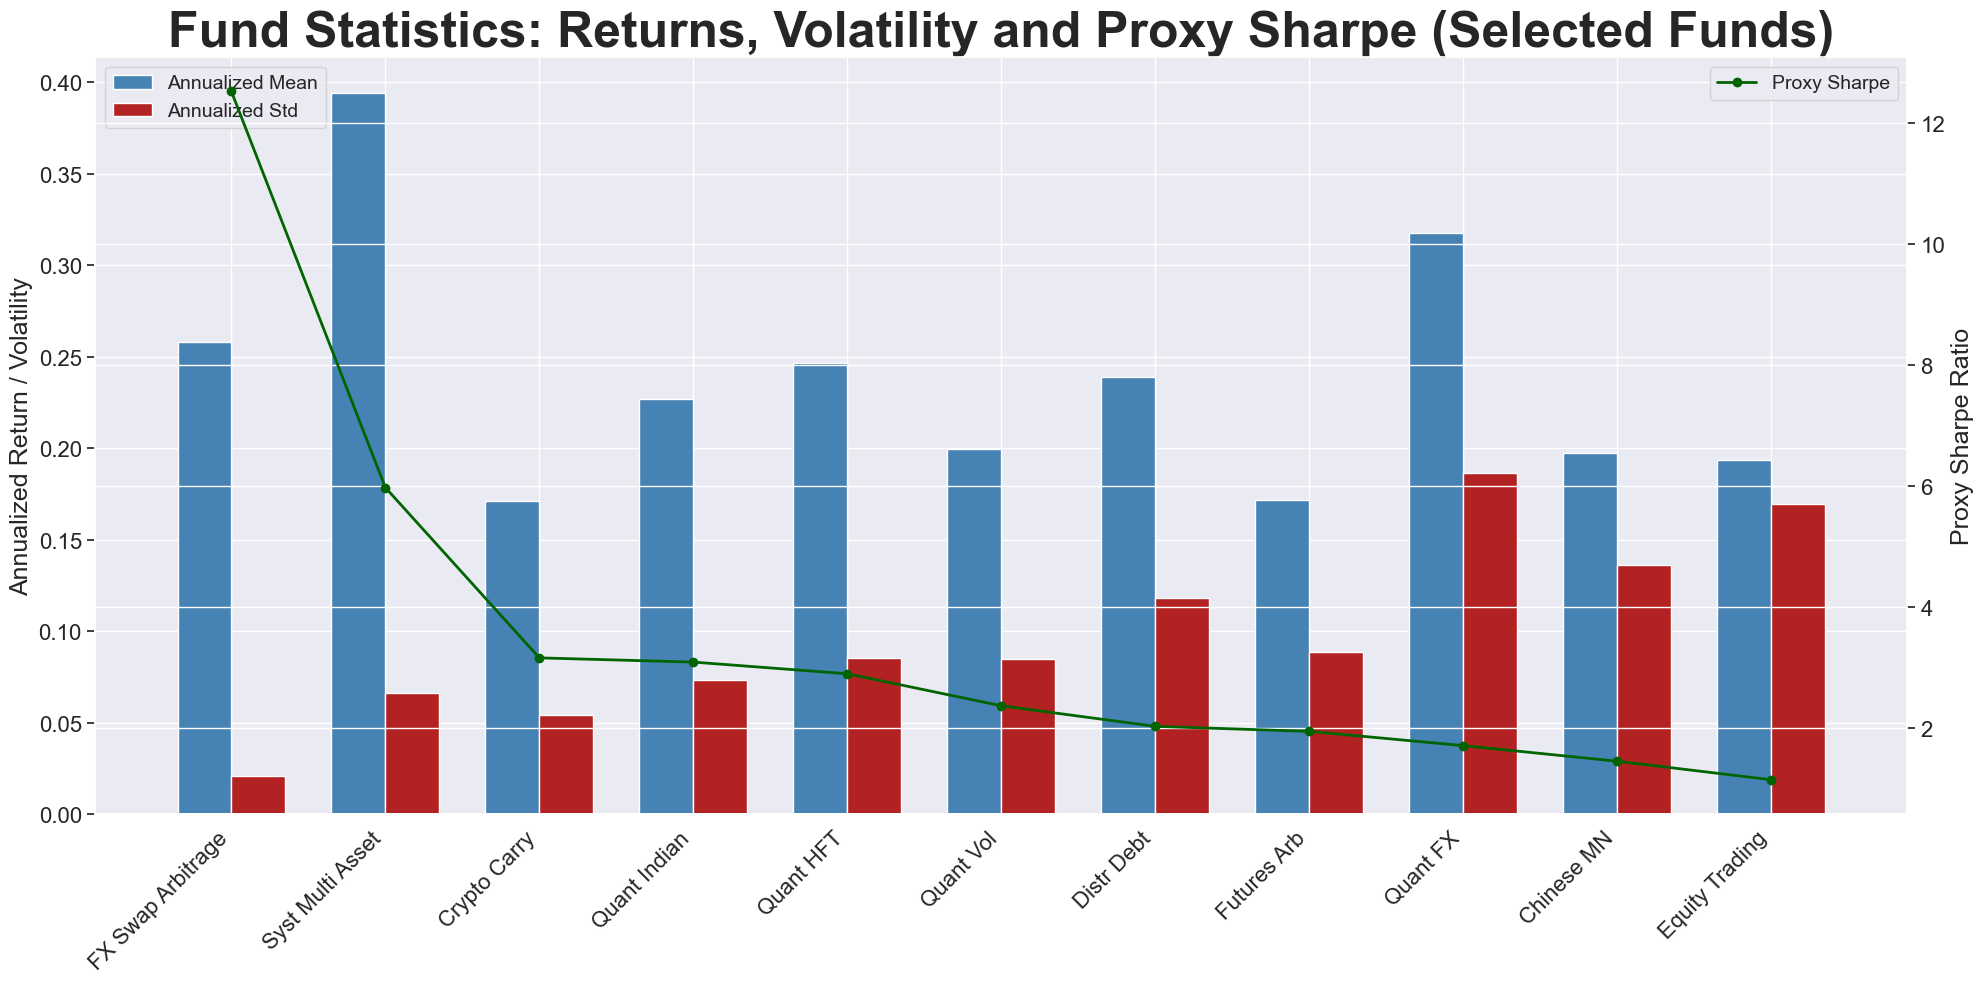

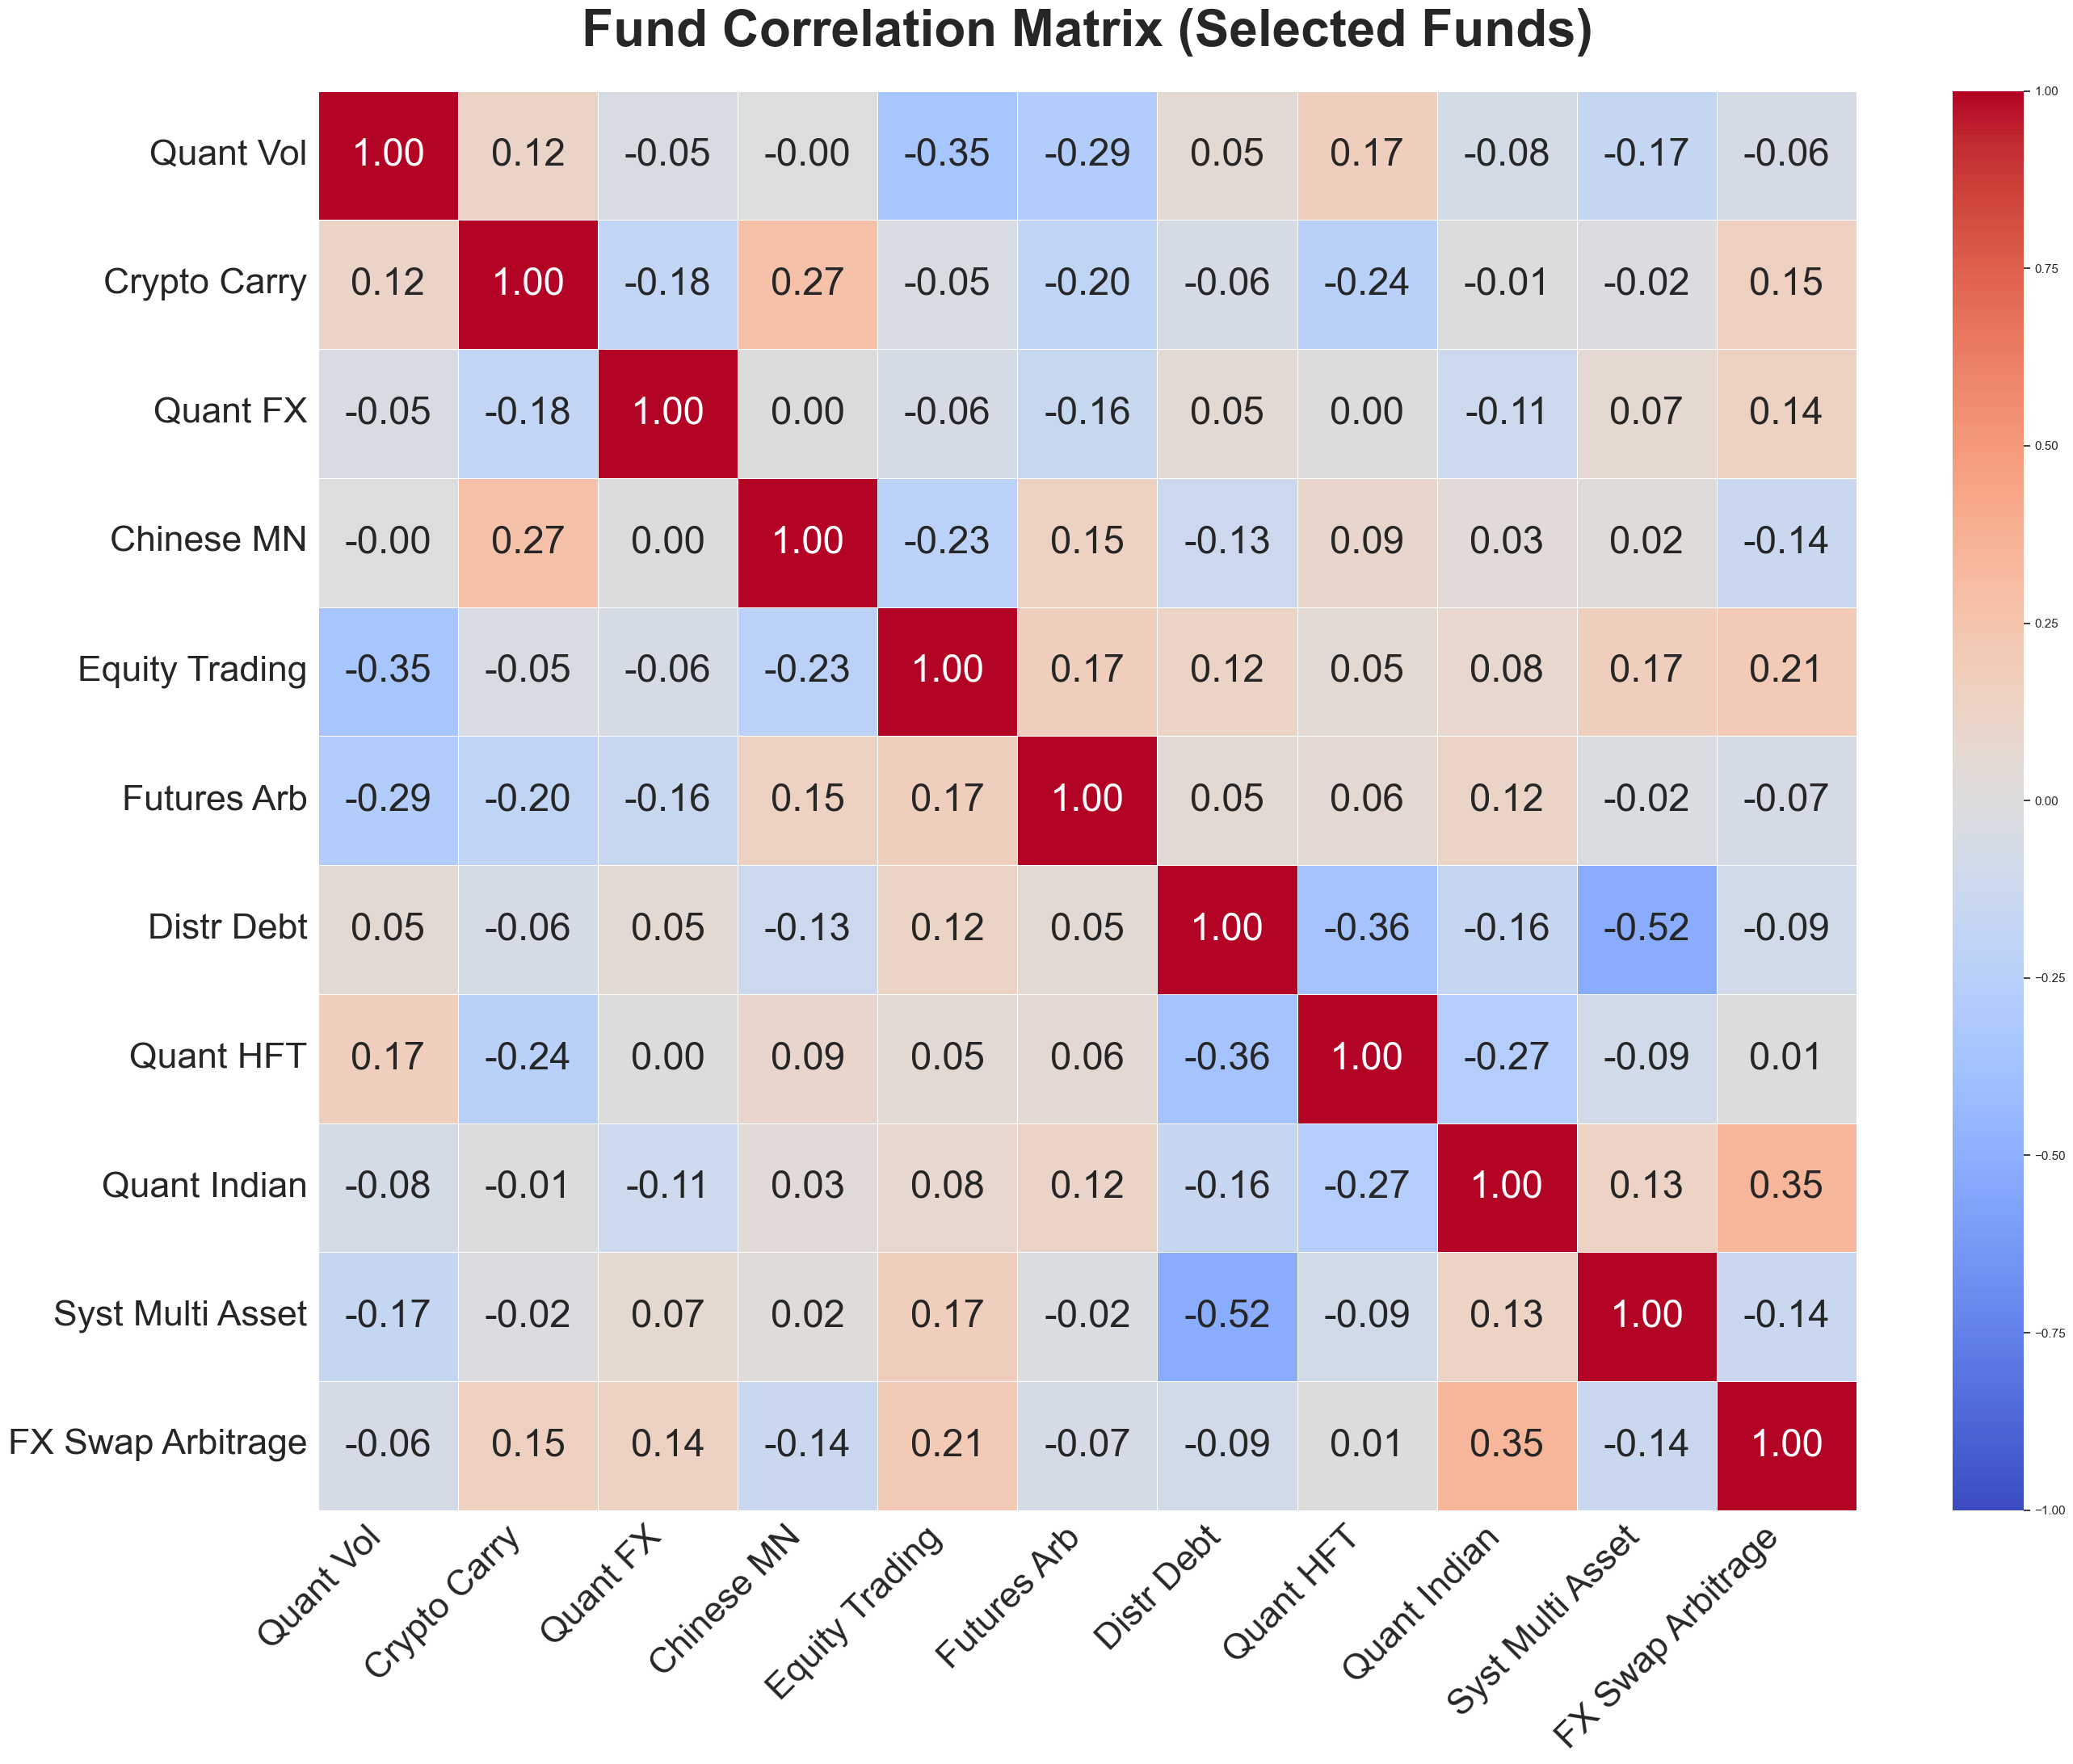

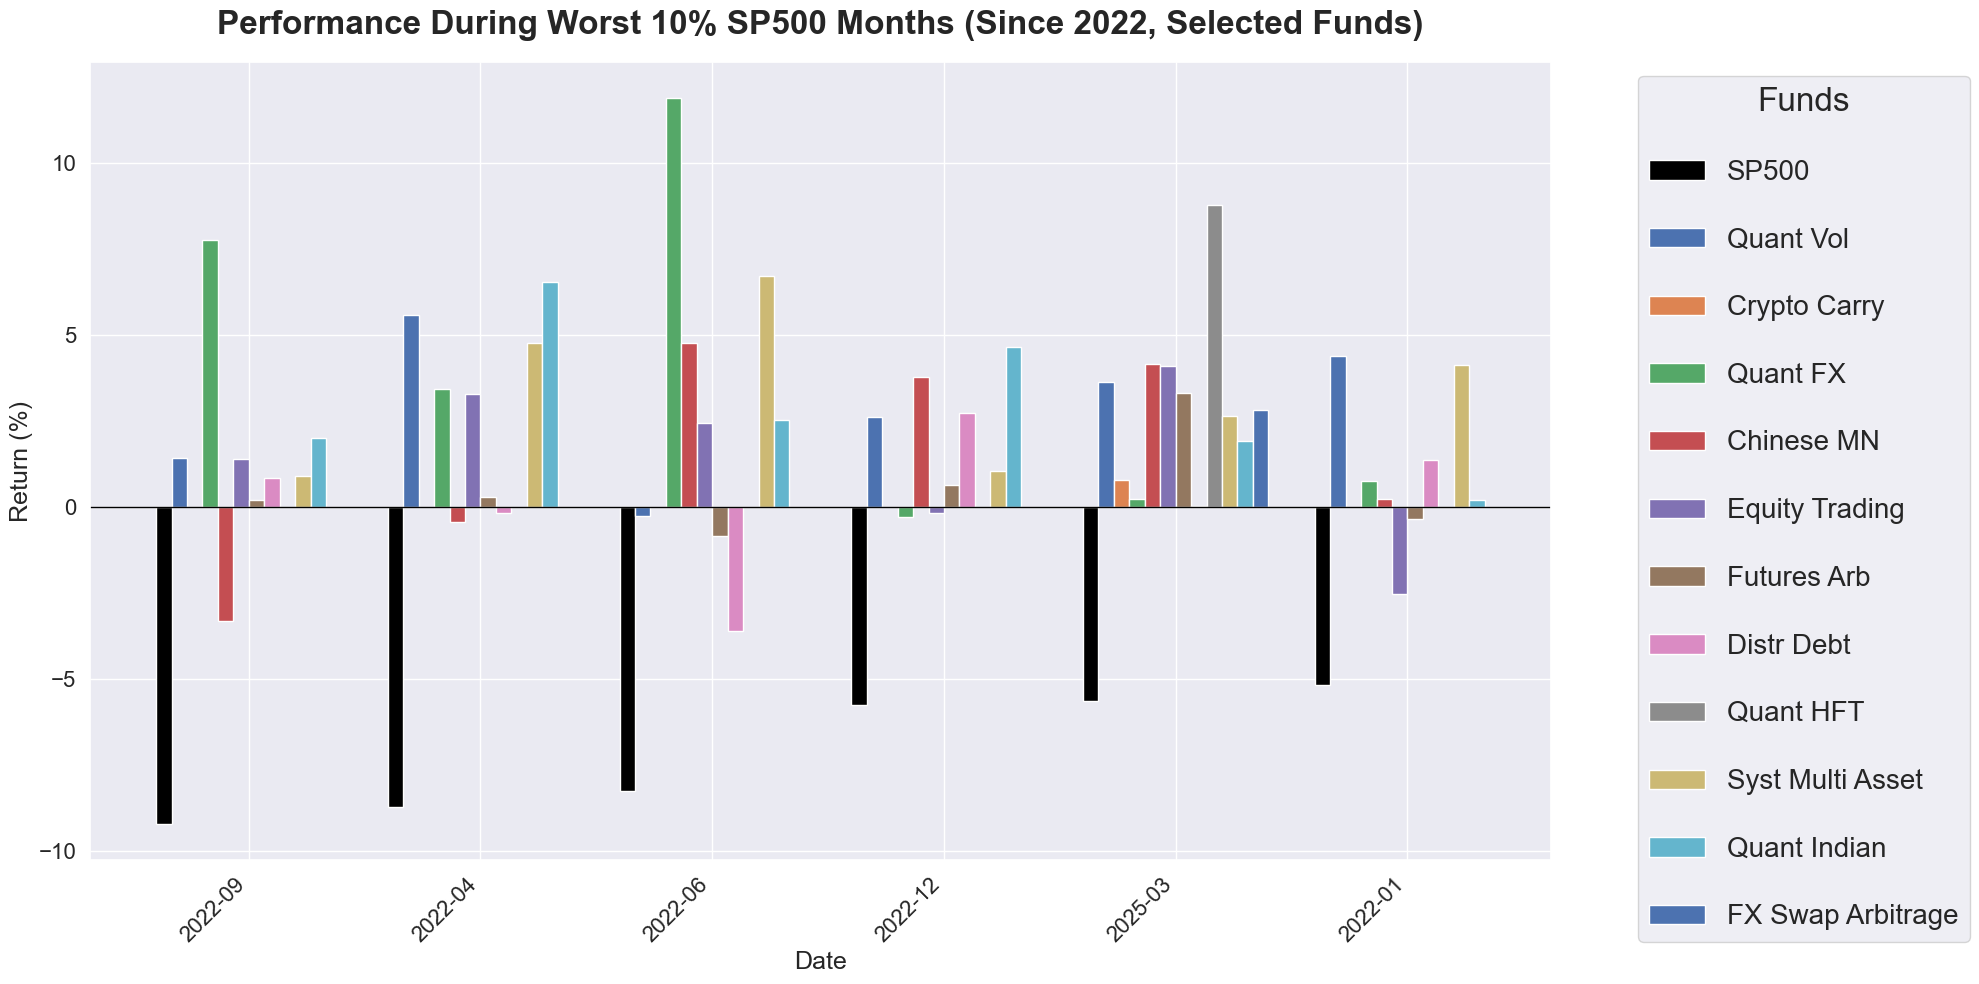

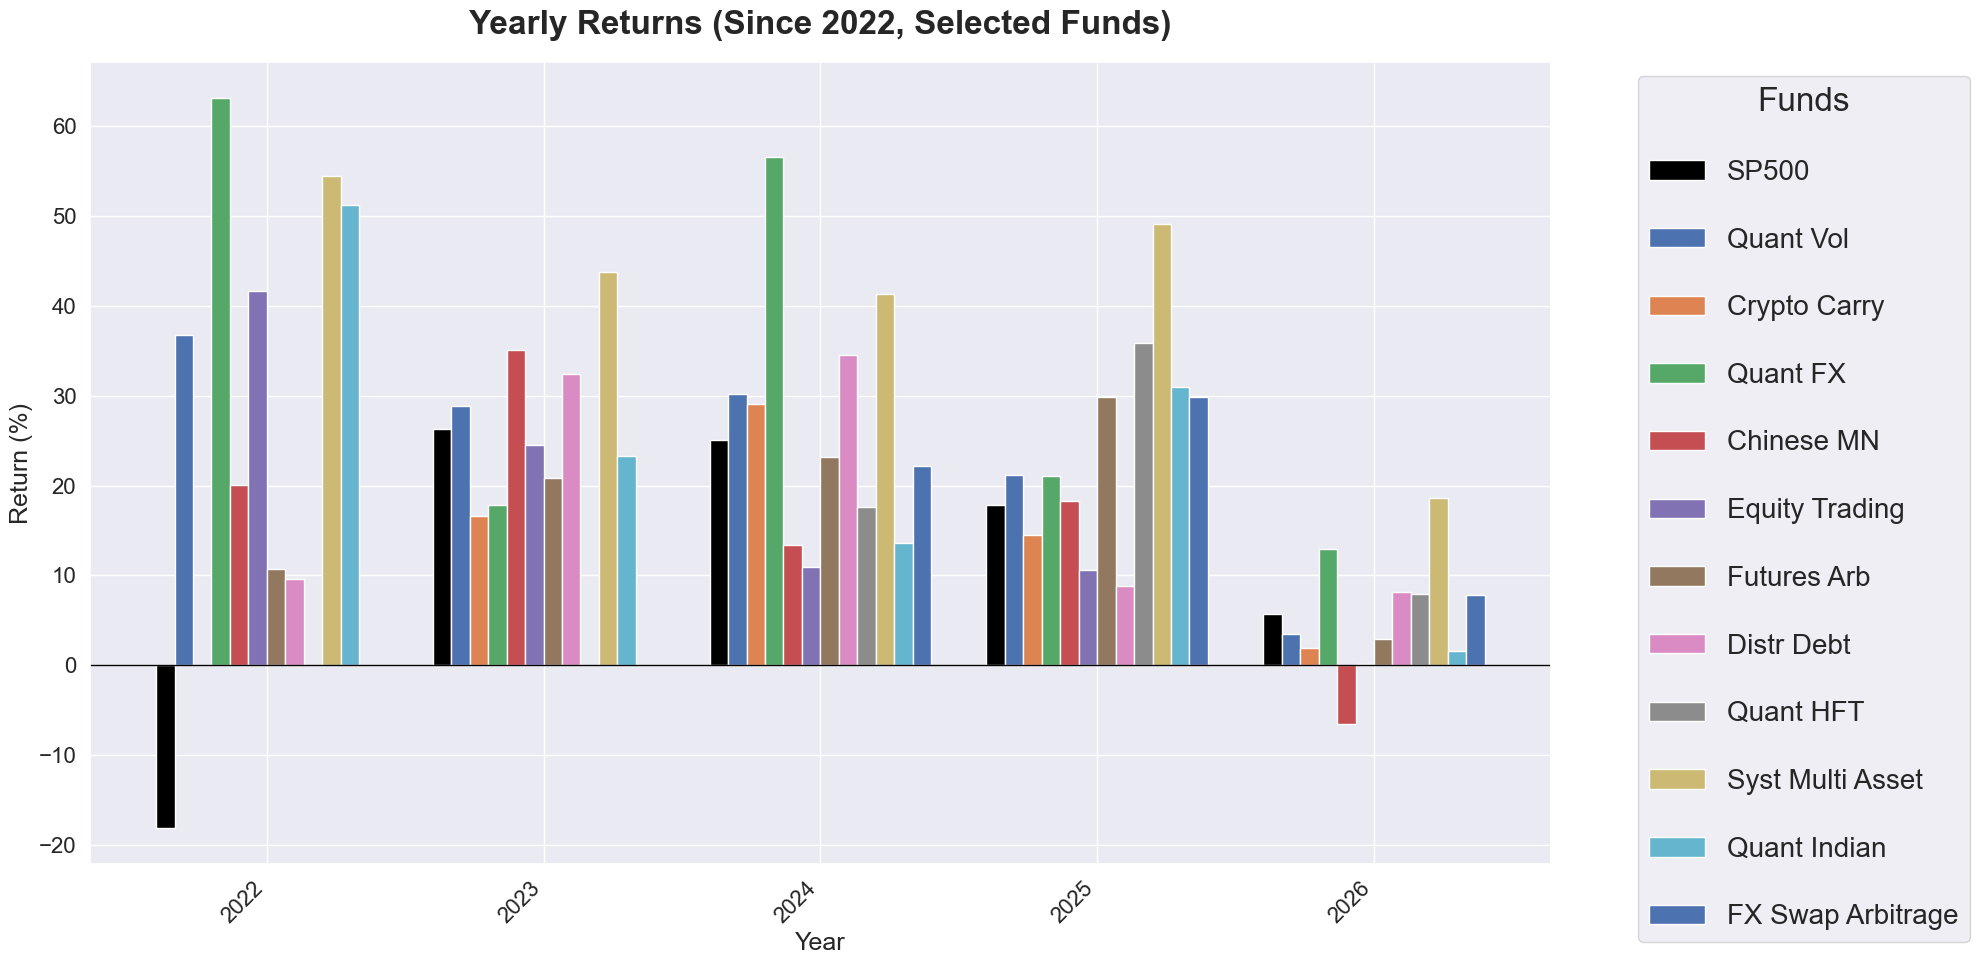

In [78]:
import os
os.makedirs("report", exist_ok=True)
# --- Selected Funds Analysis ---
selected_funds = list(allocations.keys())

# 1. Fund Statistics
stats_df_sel = stats_df_sorted.loc[stats_df_sorted.index.intersection(selected_funds)]
fig, ax1 = plt.subplots(figsize=(20, 10))
x = np.arange(len(stats_df_sel))
width = 0.35
ax1.bar(x - width/2, stats_df_sel["Annualized Mean"], width, label='Annualized Mean', color='steelblue')
ax1.bar(x + width/2, stats_df_sel["Annualized Std"], width, label='Annualized Std', color='firebrick')
ax1.set_ylabel('Annualized Return / Volatility', fontsize=18)
ax1.tick_params(axis='y', labelsize=16)
ax1.set_title('Fund Statistics: Returns, Volatility and Proxy Sharpe (Selected Funds)', fontsize=36, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([fund_short_names.get(str(c), 'Generic strategy') for c in stats_df_sel.index], rotation=45, ha='right', fontsize=16)
ax1.legend(loc='upper left', fontsize=14)
ax2 = ax1.twinx()
ax2.plot(x, stats_df_sel["Proxy Sharpe"], color='darkgreen', marker='o', linewidth=2, label='Proxy Sharpe')
ax2.set_ylabel('Proxy Sharpe Ratio', fontsize=18)
ax2.tick_params(axis='y', labelsize=16)
ax2.legend(loc='upper right', fontsize=14)
plt.tight_layout()
fig.savefig("report/fund_stats.pdf", bbox_inches="tight")
plt.show()

# 2. Correlation Matrix
corr_matrix_sel = df_funds_full[df_funds_full.columns.intersection(selected_funds)].corr()
corr_matrix_sel.rename(columns=lambda x: fund_short_names.get(x, 'Generic strategy'), index=lambda x: fund_short_names.get(x, 'Generic strategy'), inplace=True)
plt.figure(figsize=(28, 22))
sns.heatmap(corr_matrix_sel, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5, annot_kws={"size": 34})
plt.xticks(fontsize=32, rotation=45, ha='right')
plt.yticks(fontsize=32, rotation=0)
plt.title('Fund Correlation Matrix (Selected Funds)', fontsize=46, fontweight='bold', pad=40)  # pad controls space between title and plot
plt.tight_layout()
plt.savefig("report/correlation.pdf", bbox_inches="tight")
plt.show()

# 3. Worst 10% SP500 Months
# Using df_full to have sp500
df_worst = df[['sp500'] + [f for f in selected_funds if f in df.columns]].rename(columns=lambda x: fund_short_names.get(x, 'Generic strategy') if x != 'sp500' else 'sp500')
plot_worst_sp500_months_interactive(df_worst, "(Since 2022, Selected Funds)", start_date="2022-01-01", save_path="report/worst_sp500_months.pdf")

# 4. Yearly Returns
plot_yearly_returns_interactive(df_worst, "(Since 2022, Selected Funds)", start_date="2022-01-01", save_path="report/yearly_returns_all_funds.pdf")

## General Analysis

Applying the general analysis framework to each of the 4 portfolios.

In [79]:
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import yfinance as yf
from IPython.display import display, HTML

# Fetch WTI data once
sp500 = df_full['sp500'].dropna()
try:
    wti = yf.download('CL=F', start=df_full.index.min() - pd.Timedelta(days=31), end=df_full.index.max() + pd.Timedelta(days=31), progress=False)
    if isinstance(wti.columns, pd.MultiIndex):
        wti_close = wti['Close']['CL=F'].to_frame()
    else:
        wti_close = wti[['Close']]
    
    wti_monthly = wti_close.resample('ME').last()
    wti_returns = wti_monthly.pct_change()
    wti_returns.index = wti_returns.index.to_period('M').to_timestamp()
    wti_returns.columns = ['wti_return']
    
    analysis_df = df_full.join(wti_returns)
except Exception as e:
    print(f"Error fetching WTI data: {e}")
    analysis_df = df_full.copy()

def bootstrap_corr(x, y, method='pearson', block_size=1, iters=1000):
    np.random.seed(42)
    n = len(x)
    corrs = []
    indices = np.arange(n)
    for _ in range(iters):
        if block_size == 1:
            idx = np.random.choice(indices, size=n, replace=True)
        else:
            num_blocks = int(np.ceil(n / block_size))
            block_starts = np.random.choice(n - block_size + 1, size=num_blocks, replace=True)
            idx = [i for start in block_starts for i in range(start, start + block_size)][:n]
        x_samp = x.iloc[idx]
        y_samp = y.iloc[idx]
        corrs.append(x_samp.corr(y_samp, method=method))
    return np.nanpercentile(corrs, 2.5), np.nanpercentile(corrs, 97.5)


--- Dataset Info ---
Start Date: 2022-01-01
End Date:   2026-04-01
Time Elapsed: 1551 days (4.25 years)
Total Data Points: 52 months

--- Positive Months (Hit Rates) ---
Fund Positive Months:  100.00% (52/52)
SP500 Positive Months: 63.46% (33/52)

--- Conditional Hit Rates ---
Fund Positive when SP500 Negative: 100.00% (19/19)
Fund Negative when SP500 Positive: 0.00% (0/33)

--- Trading Metrics (n=52 months) ---
Annualized Mean Return: 0.2033
Annualized Volatility:  0.0264
Sharpe Ratio:           7.6881
CAGR:                   0.2229
Max Drawdown:           0.0000
Calmar Ratio:           nan

--- Joint Metrics (n=52 months) ---
Pearson Correlation:  -0.0126
  - 95% CI (Standard Bootstrap): [-0.2684, 0.2625]
  - 95% CI (Block=3 Bootstrap):  [-0.2426, 0.3257]
Spearman Correlation: 0.0238
  - 95% CI (Standard Bootstrap): [-0.2511, 0.2897]
  - 95% CI (Block=3 Bootstrap):  [-0.2140, 0.3356]
Regression Alpha (Annualized): 0.2035 (t-stat: 15.4927)
Regression Beta:               -0.0020 (t-sta

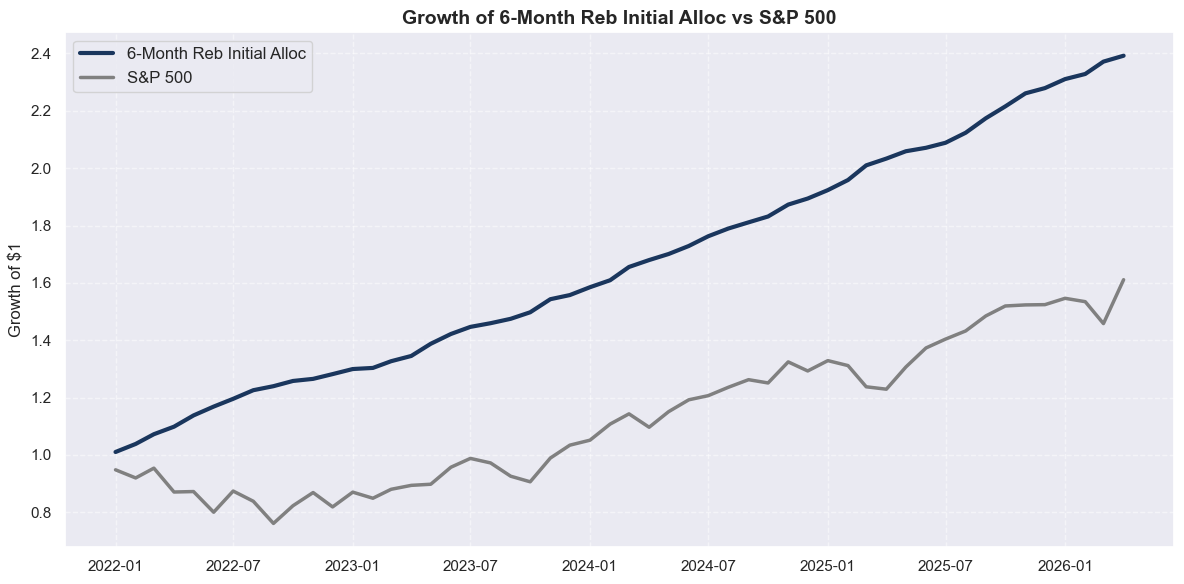

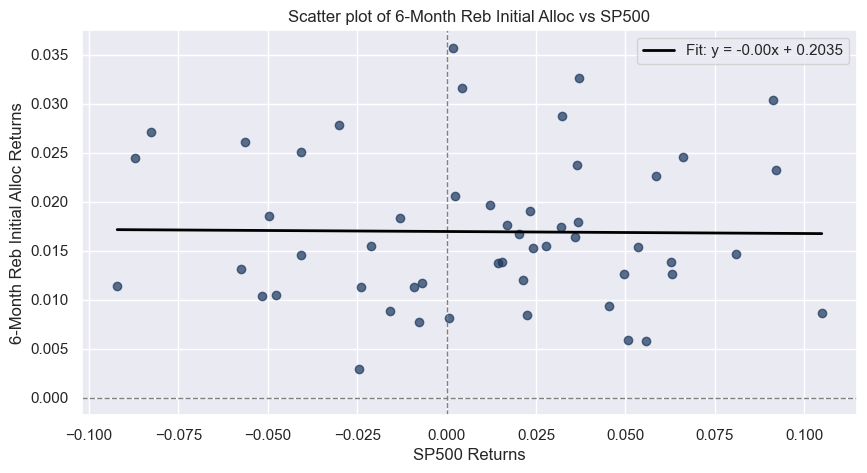

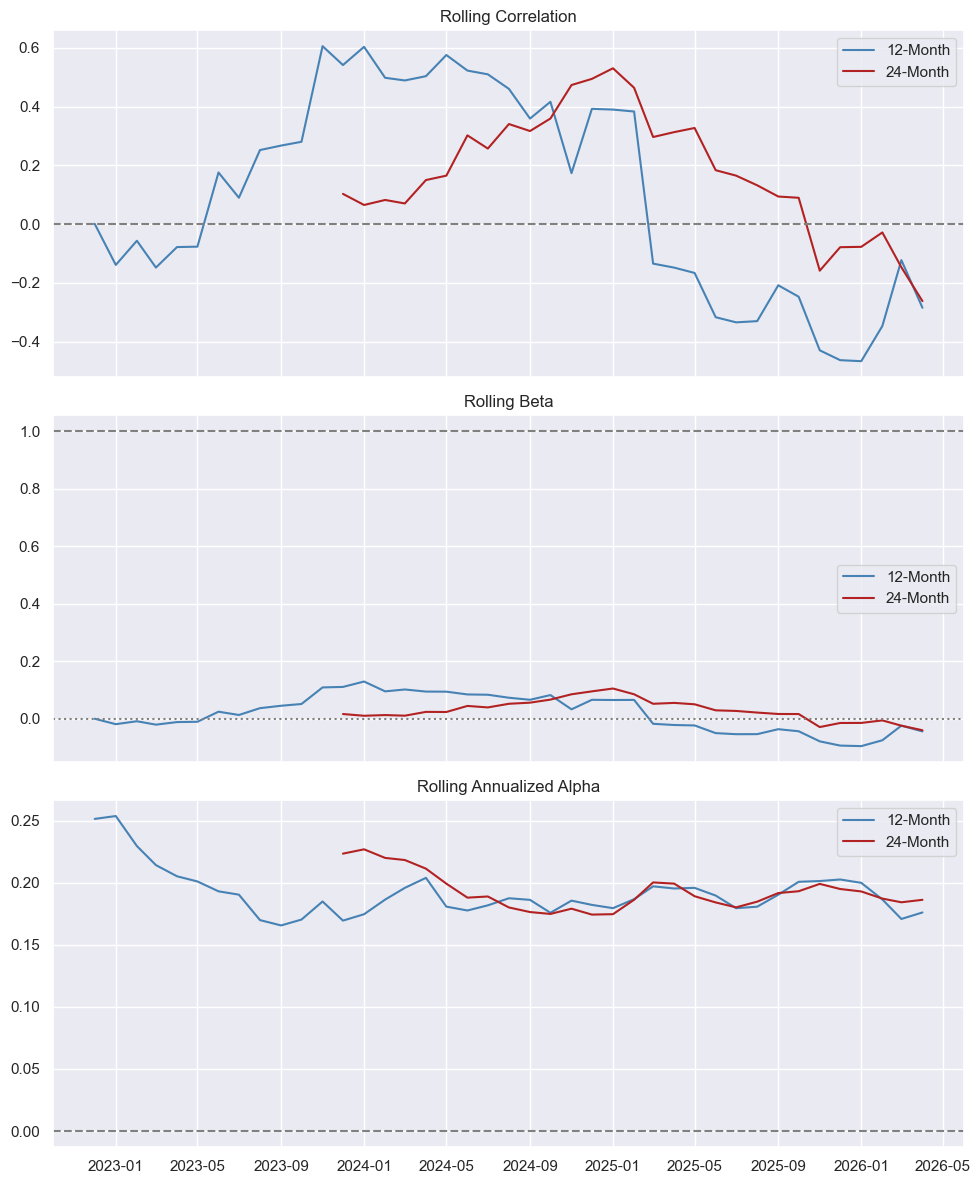

In [80]:
# Run analysis for each portfolio
for port_name in portfolios_df.columns:
    display(HTML(f"<h3 style='color: firebrick;'>============================================<br>ANALYSIS FOR {port_name}<br>============================================</h3>"))
    
    fund = portfolios_df[port_name]
    
    # Align dates
    common_idx = fund.index.intersection(sp500.index)
    fund_aligned = fund.loc[common_idx]
    sp500_aligned = sp500.loc[common_idx]
    
    n_months = len(fund_aligned)
    if n_months == 0:
        continue
        
    start_date = fund_aligned.index.min()
    end_date = fund_aligned.index.max()
    time_elapsed = end_date - start_date
    years_elapsed = time_elapsed.days / 365.25

    print("--- Dataset Info ---")
    print(f"Start Date: {start_date.date()}")
    print(f"End Date:   {end_date.date()}")
    print(f"Time Elapsed: {time_elapsed.days} days ({years_elapsed:.2f} years)")
    print(f"Total Data Points: {n_months} months")

    fund_pos_months = (fund_aligned > 0).sum()
    sp500_pos_months = (sp500_aligned > 0).sum()
    print("\n--- Positive Months (Hit Rates) ---")
    print(f"Fund Positive Months:  {fund_pos_months/n_months:.2%} ({fund_pos_months}/{n_months})")
    print(f"SP500 Positive Months: {sp500_pos_months/n_months:.2%} ({sp500_pos_months}/{n_months})")

    sp500_neg_mask = sp500_aligned < 0
    sp500_pos_mask = sp500_aligned > 0
    n_sp500_neg = sp500_neg_mask.sum()
    n_sp500_pos = sp500_pos_mask.sum()

    fund_pos_when_sp500_neg = (fund_aligned[sp500_neg_mask] > 0).sum()
    fund_neg_when_sp500_pos = (fund_aligned[sp500_pos_mask] < 0).sum()
    print("\n--- Conditional Hit Rates ---")
    print(f"Fund Positive when SP500 Negative: {fund_pos_when_sp500_neg / n_sp500_neg if n_sp500_neg > 0 else np.nan:.2%} ({fund_pos_when_sp500_neg}/{n_sp500_neg})")
    print(f"Fund Negative when SP500 Positive: {fund_neg_when_sp500_pos / n_sp500_pos if n_sp500_pos > 0 else np.nan:.2%} ({fund_neg_when_sp500_pos}/{n_sp500_pos})")

    # Trading Metrics
    mean_ret = fund_aligned.mean() * 12
    vol = fund_aligned.std() * np.sqrt(12)
    sharpe = mean_ret / vol if vol != 0 else np.nan

    cum_ret = (1 + fund_aligned).prod()
    n_years = n_months / 12
    cagr = cum_ret**(1/n_years) - 1

    cum_wealth = (1 + fund_aligned).cumprod()
    peak = cum_wealth.cummax()
    drawdown = (cum_wealth - peak) / peak
    max_drawdown = drawdown.min()

    calmar = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan

    print(f"\n--- Trading Metrics (n={n_months} months) ---")
    print(f"Annualized Mean Return: {mean_ret:.4f}")
    print(f"Annualized Volatility:  {vol:.4f}")
    print(f"Sharpe Ratio:           {sharpe:.4f}")
    print(f"CAGR:                   {cagr:.4f}")
    print(f"Max Drawdown:           {max_drawdown:.4f}")
    print(f"Calmar Ratio:           {calmar:.4f}")

    # Joint Metrics
    pearson_corr = fund_aligned.corr(sp500_aligned, method='pearson')
    spearman_corr = fund_aligned.corr(sp500_aligned, method='spearman')

    pearson_std_ci = bootstrap_corr(fund_aligned, sp500_aligned, method='pearson', block_size=1)
    pearson_blk_ci = bootstrap_corr(fund_aligned, sp500_aligned, method='pearson', block_size=3)
    spearman_std_ci = bootstrap_corr(fund_aligned, sp500_aligned, method='spearman', block_size=1)
    spearman_blk_ci = bootstrap_corr(fund_aligned, sp500_aligned, method='spearman', block_size=3)

    X = sm.add_constant(sp500_aligned)
    model = sm.OLS(fund_aligned, X).fit()
    alpha = model.params['const'] * 12
    alpha_t = model.tvalues['const']
    beta = model.params['sp500']
    alpha_tstat = model.tvalues['const']
    beta_tstat = model.tvalues['sp500']

    print(f"\n--- Joint Metrics (n={n_months} months) ---")
    print(f"Pearson Correlation:  {pearson_corr:.4f}")
    print(f"  - 95% CI (Standard Bootstrap): [{pearson_std_ci[0]:.4f}, {pearson_std_ci[1]:.4f}]")
    print(f"  - 95% CI (Block=3 Bootstrap):  [{pearson_blk_ci[0]:.4f}, {pearson_blk_ci[1]:.4f}]")
    print(f"Spearman Correlation: {spearman_corr:.4f}")
    print(f"  - 95% CI (Standard Bootstrap): [{spearman_std_ci[0]:.4f}, {spearman_std_ci[1]:.4f}]")
    print(f"  - 95% CI (Block=3 Bootstrap):  [{spearman_blk_ci[0]:.4f}, {spearman_blk_ci[1]:.4f}]")
    print(f"Regression Alpha (Annualized): {alpha:.4f} (t-stat: {alpha_tstat:.4f})")
    print(f"Regression Beta:               {beta:.4f} (t-stat: {beta_tstat:.4f})")

    if 'wti_return' in analysis_df.columns:
        wti_clean = pd.DataFrame({'wti_return': analysis_df['wti_return'], 'fund': fund}).dropna()
        if len(wti_clean) > 10:
            X_wti = sm.add_constant(wti_clean['wti_return'])
            model_wti = sm.OLS(wti_clean['fund'], X_wti).fit()
            print(f"\n--- WTI Joint Metrics (n={len(wti_clean)} months) ---")
            print(f"Regression Alpha (Annualized): {model_wti.params['const'] * 12:.4f} (t-stat: {model_wti.tvalues['const']:.4f})")
            print(f"Regression Beta (WTI):         {model_wti.params['wti_return']:.4f} (t-stat: {model_wti.tvalues['wti_return']:.4f})")

    # Capture Ratios
    up_months_fund = fund_aligned[sp500_pos_mask]
    down_months_fund = fund_aligned[sp500_neg_mask]
    
    up_capture = up_months_fund.mean() / sp500_aligned[sp500_pos_mask].mean() if len(up_months_fund) > 0 else np.nan
    down_capture = down_months_fund.mean() / sp500_aligned[sp500_neg_mask].mean() if len(down_months_fund) > 0 else np.nan

    print("\n--- Capture Ratios ---")
    print(f"Upside Capture:   {up_capture:.4f} (n={len(up_months_fund)})")
    print(f"Downside Capture: {down_capture:.4f} (n={len(down_months_fund)})")

    # Conditional Metrics
    if len(up_months_fund) > 2:
        model_up = sm.OLS(up_months_fund, sm.add_constant(sp500_aligned[sp500_pos_mask])).fit()
        print(f"\n--- Up Months Metrics (n={len(up_months_fund)}) ---")
        print(f"Up Alpha (Annualized): {model_up.params['const'] * 12:.4f} (t-stat: {model_up.tvalues['const']:.4f})")
        print(f"Up Beta:               {model_up.params['sp500']:.4f} (t-stat: {model_up.tvalues['sp500']:.4f})")
    
    if len(down_months_fund) > 2:
        model_down = sm.OLS(down_months_fund, sm.add_constant(sp500_aligned[sp500_neg_mask])).fit()
        print(f"\n--- Down Months Metrics (n={len(down_months_fund)}) ---")
        print(f"Down Alpha (Annualized): {model_down.params['const'] * 12:.4f} (t-stat: {model_down.tvalues['const']:.4f})")
        print(f"Down Beta:               {model_down.params['sp500']:.4f} (t-stat: {model_down.tvalues['sp500']:.4f})")


    # Plot Growth vs S&P 500
    cum_p = (1 + fund_aligned).cumprod()
    cum_s = (1 + sp500_aligned).cumprod()
    plt.figure(figsize=(12, 6))
    plt.plot(cum_p.index, cum_p, label=port_name, color='#1A365D', linewidth=3)
    plt.plot(cum_s.index, cum_s, label='S&P 500', color='gray', linewidth=2.5, linestyle='-')
    plt.title(f'Growth of {port_name} vs S&P 500', fontsize=14, fontweight='bold')
    plt.ylabel('Growth of $1', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=12, loc='upper left')
    plt.tight_layout()
    safe_name = port_name.replace(' ', '_').replace('-', '_').lower()
    plt.savefig(f'report/growth_{safe_name}_vs_sp500.pdf', bbox_inches='tight')
    plt.show()

    # Plots (Scatter)
    plt.figure(figsize=(10, 5))
    plt.scatter(sp500_aligned, fund_aligned, alpha=0.7, color='#1A365D')
    plt.axvline(0, color='gray', linestyle='--', linewidth=1)
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.xlabel('SP500 Returns')
    plt.ylabel(f'{port_name} Returns')
    plt.title(f'Scatter plot of {port_name} vs SP500')
    
    x_vals = np.linspace(sp500_aligned.min(), sp500_aligned.max(), 100)
    y_vals = model.params['sp500'] * x_vals + model.params['const']
    plt.plot(x_vals, y_vals, color='black', linewidth=2, label=f"Fit: y = {model.params['sp500']:.2f}x + {model.params['const'] * 12:.4f}")
    plt.legend()
    safe_name = port_name.replace(' ', '_').replace('-', '_').lower()
    plt.savefig(f'report/scatter_{safe_name}_vs_sp500.pdf', bbox_inches='tight')
    plt.show()

    # Rolling Metrics
    if n_months > 24:
        roll_corr_12 = fund_aligned.rolling(12).corr(sp500_aligned)
        roll_corr_24 = fund_aligned.rolling(24).corr(sp500_aligned)

        X_roll = sm.add_constant(sp500_aligned)
        roll_model_12 = RollingOLS(fund_aligned, X_roll, window=12).fit()
        roll_model_24 = RollingOLS(fund_aligned, X_roll, window=24).fit()

        fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
        axes[0].plot(roll_corr_12, label='12-Month', color='steelblue')
        axes[0].plot(roll_corr_24, label='24-Month', color='firebrick')
        axes[0].axhline(0, color='grey', linestyle='--')
        axes[0].set_title(f'Rolling Correlation')
        axes[0].legend()

        axes[1].plot(roll_model_12.params['sp500'], label='12-Month', color='steelblue')
        axes[1].plot(roll_model_24.params['sp500'], label='24-Month', color='firebrick')
        axes[1].axhline(1, color='grey', linestyle='--')
        axes[1].axhline(0, color='grey', linestyle=':')
        axes[1].set_title(f'Rolling Beta')
        axes[1].legend()

        axes[2].plot(roll_model_12.params['const']*12, label='12-Month', color='steelblue')
        axes[2].plot(roll_model_24.params['const']*12, label='24-Month', color='firebrick')
        axes[2].axhline(0, color='grey', linestyle='--')
        axes[2].set_title(f'Rolling Annualized Alpha')
        axes[2].legend()

        plt.tight_layout()
        plt.show()


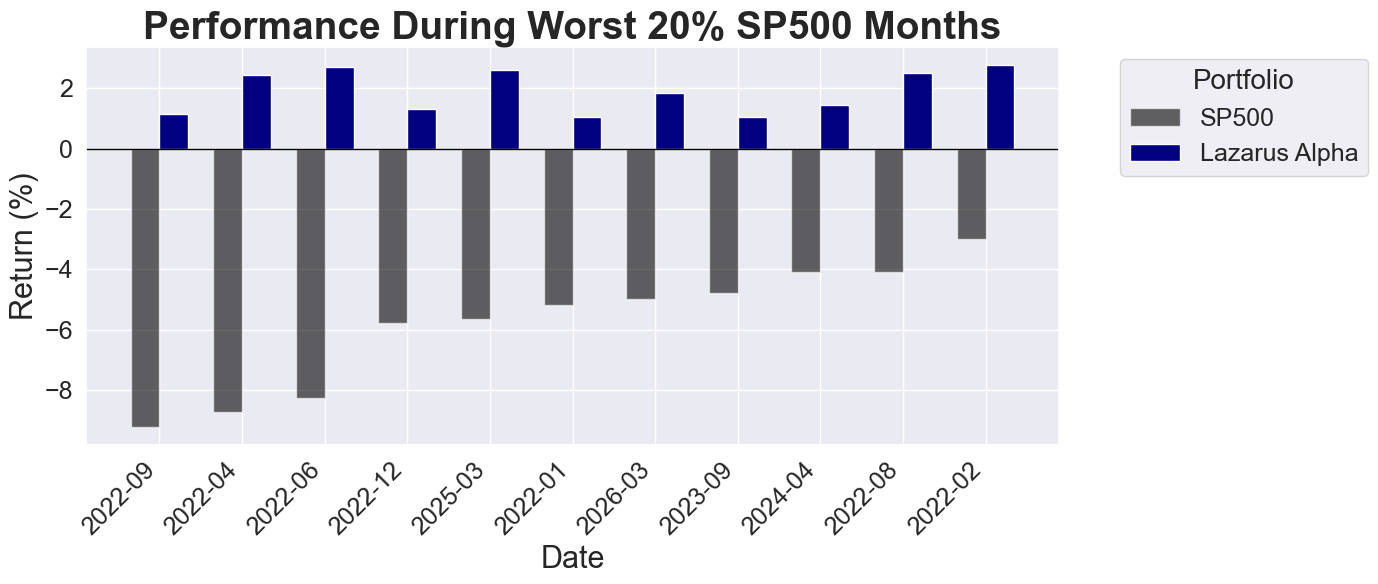

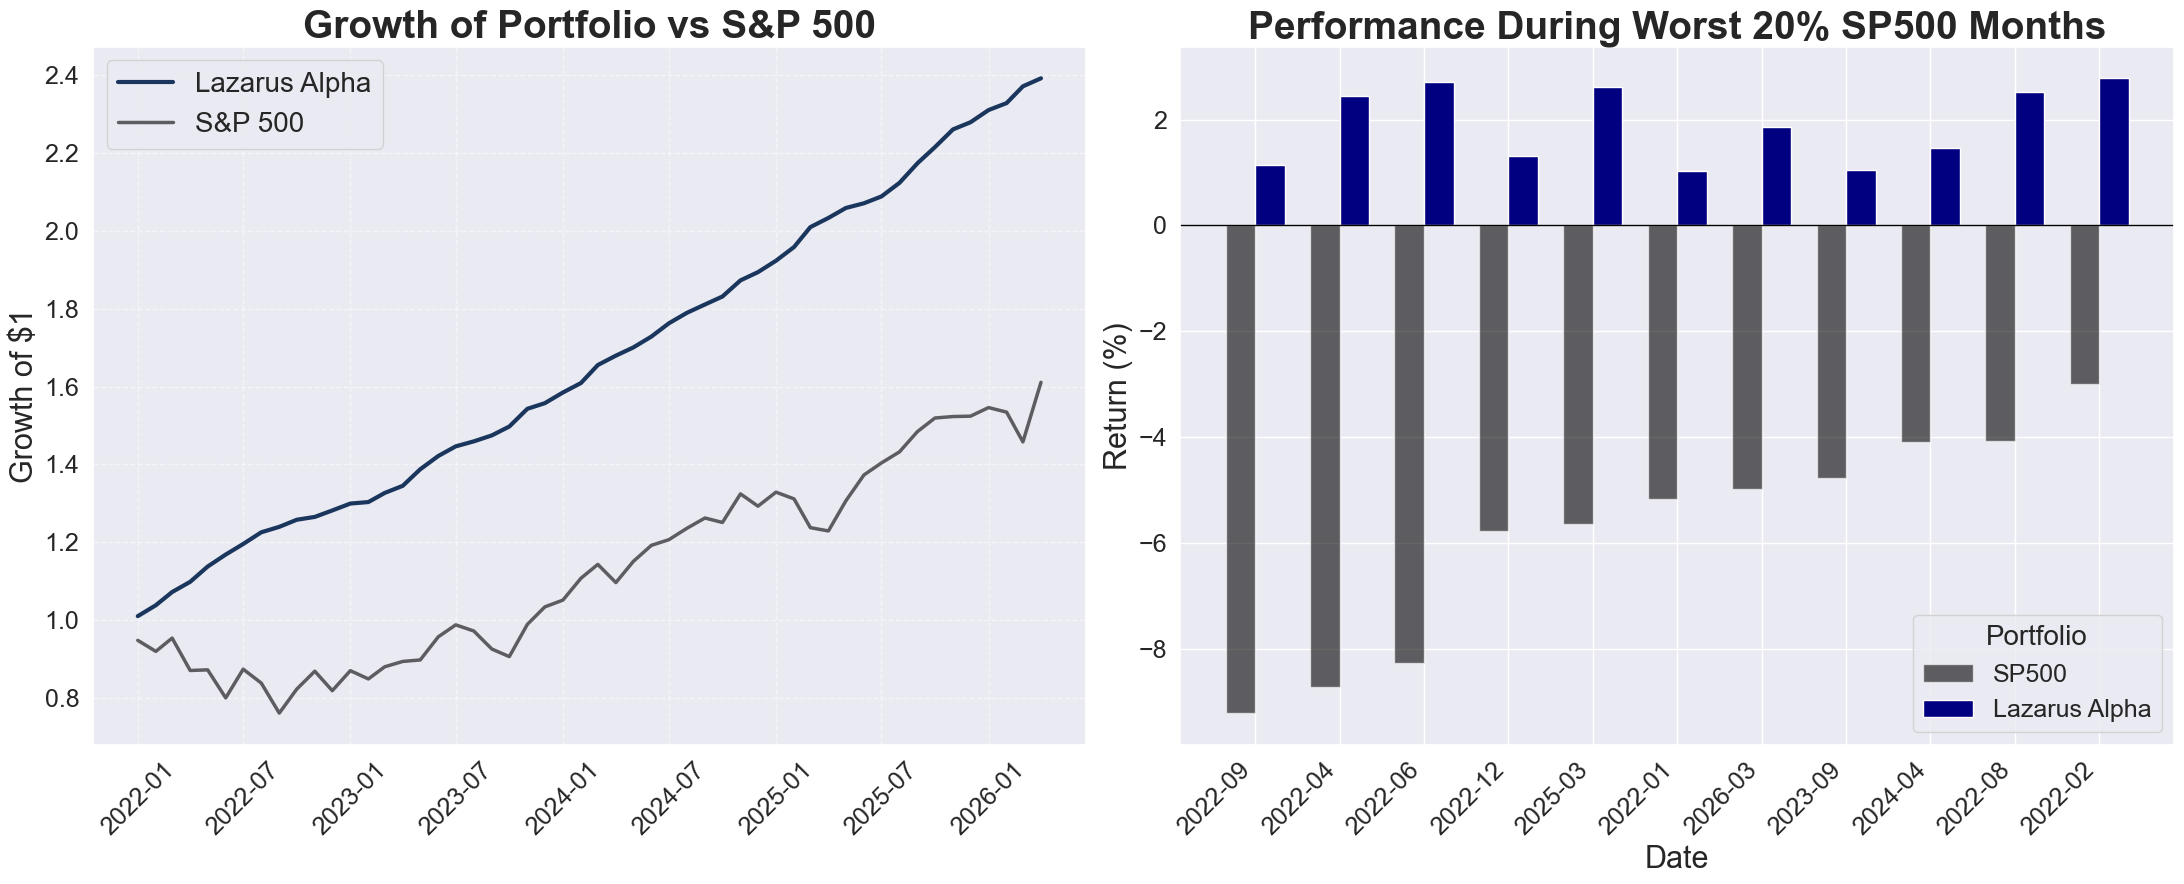

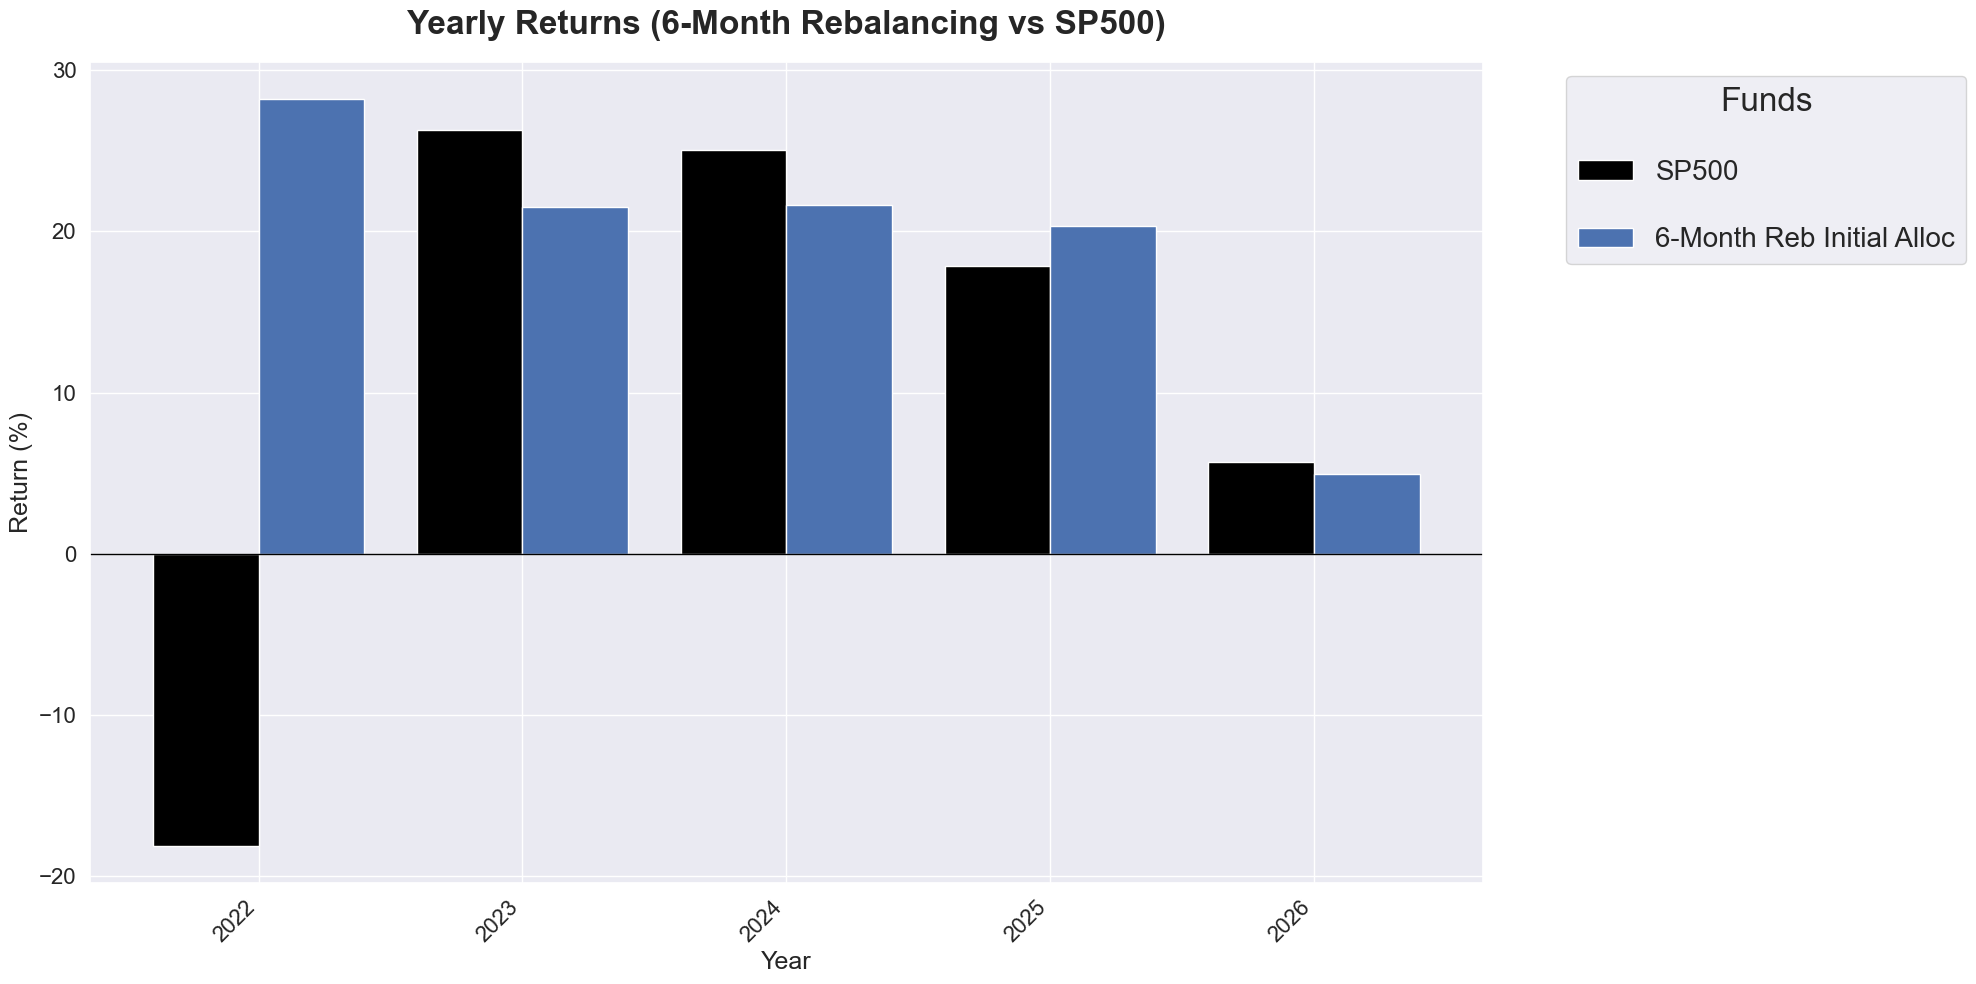

In [81]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Ensure report directory exists
os.makedirs('report', exist_ok=True)

port_name = '6-Month Reb Initial Alloc'

# Prepare data: 6-Month Reb Initial Alloc vs SP500
plot_df = pd.concat([df_full['sp500'], all_portfolios_df[port_name]], axis=1).dropna()

# Find worst 20% SP500 months
q20_sp500 = plot_df['sp500'].quantile(0.20)
worst_months = plot_df[plot_df['sp500'] <= q20_sp500].copy()

# Sort by SP500 returns ascending
worst_months = worst_months.sort_values(by='sp500', ascending=True)

# Prepare data for plotting
worst_months_plot = worst_months.copy()
worst_months_plot.index = worst_months_plot.index.strftime('%Y-%m') # Format dates for x-axis
worst_months_plot = worst_months_plot * 100 # Convert to percentage

# ---------------------------------------------------------
# 1. Standalone Plot: Worst 20% SP500 Months
# ---------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(14, 6))
x = np.arange(len(worst_months_plot))
width = 0.35

# SP500 in less dark black (black with alpha=0.6)
ax1.bar(x - width/2, worst_months_plot['sp500'], width, label='SP500', color='black', alpha=0.6)
ax1.bar(x + width/2, worst_months_plot[port_name], width, label='Lazarus Alpha', color='navy')

ax1.set_title('Performance During Worst 20% SP500 Months', fontsize=28, fontweight='bold')
ax1.set_xlabel('Date', fontsize=22)
ax1.set_ylabel('Return (%)', fontsize=22)
ax1.set_xticks(x)
ax1.set_xticklabels(worst_months_plot.index, rotation=45, ha='right', fontsize=18)
ax1.tick_params(axis='y', labelsize=18)
ax1.legend(title='Portfolio', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=18, title_fontsize=20)
ax1.axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.savefig('report/worst20_sp500_6m_reb.pdf', bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 2. Combined Plot: Growth and Worst 20% SP500 Months (Side-by-Side)
# ---------------------------------------------------------
# Align data for the growth plot
sp500_aligned, fund_aligned = df_full['sp500'].align(all_portfolios_df[port_name], join='inner')
sp500_aligned = sp500_aligned.dropna()
fund_aligned = fund_aligned.reindex(sp500_aligned.index)

cum_p = (1 + fund_aligned).cumprod()
cum_s = (1 + sp500_aligned).cumprod()

fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(22, 9))

# Left Subplot: Growth
ax2a.plot(cum_p.index, cum_p, label='Lazarus Alpha', color='#1A365D', linewidth=3)
ax2a.plot(cum_s.index, cum_s, label='S&P 500', color='black', alpha=0.6, linewidth=2.5, linestyle='-')
ax2a.set_title('Growth of Portfolio vs S&P 500', fontsize=28, fontweight='bold')
ax2a.set_ylabel('Growth of $1', fontsize=22)
ax2a.tick_params(axis='y', labelsize=18)
ax2a.tick_params(axis='x', labelsize=18, rotation=45)
ax2a.grid(True, linestyle='--', alpha=0.5)
ax2a.legend(fontsize=20, loc='upper left')

# Right Subplot: Worst 20%
ax2b.bar(x - width/2, worst_months_plot['sp500'], width, label='SP500', color='black', alpha=0.6)
ax2b.bar(x + width/2, worst_months_plot[port_name], width, label='Lazarus Alpha', color='navy')
ax2b.set_title('Performance During Worst 20% SP500 Months', fontsize=28, fontweight='bold')
ax2b.set_xlabel('Date', fontsize=22)
ax2b.set_ylabel('Return (%)', fontsize=22)
ax2b.set_xticks(x)
ax2b.set_xticklabels(worst_months_plot.index, rotation=45, ha='right', fontsize=18)
ax2b.tick_params(axis='y', labelsize=18)
ax2b.legend(title='Portfolio', loc='lower right', fontsize=18, title_fontsize=20)
ax2b.axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.savefig('report/combined_growth_worst20_sp500.pdf', bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 3. Yearly Returns
# ---------------------------------------------------------
plot_yearly_returns_interactive(plot_df, "(6-Month Rebalancing vs SP500)", start_date="2022-01-01", save_path="report/yearly_returns_6m_reb.pdf")

## Dynamic PDF Report Generation
The following cell automatically generates a LaTeX PDF presentation (`presentation.pdf`) using the computed data from the notebook.

In [82]:
import os
import subprocess
import numpy as np
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create report folder so we don't pollute the repo
REPORT_DIR = 'report'
os.makedirs(REPORT_DIR, exist_ok=True)

# Helper function to escape LaTeX special characters
def escape_latex(text):
    if not isinstance(text, str):
        text = str(text)
    return text.replace('%', '\\%').replace('&', '\\&').replace('_', '\\_')

# 2. Calculate Comprehensive Statistics
def compute_stats(fund_ret, sp500_ret):
    c_idx = fund_ret.dropna().index.intersection(sp500_ret.index)
    f_align = fund_ret.loc[c_idx]
    s_align = sp500_ret.loc[c_idx]
    
    n_months = len(f_align)
    if n_months == 0: return {}
    
    n_years = n_months / 12
    cum_wealth = (1 + f_align).cumprod()
    cagr = cum_wealth.iloc[-1]**(1/n_years) - 1 if cum_wealth.iloc[-1] > 0 else np.nan
    std = f_align.std() * np.sqrt(12)
    proxy_sharpe = (f_align.mean() * 12) / std if std != 0 else np.nan
    
    peak = cum_wealth.cummax()
    mdd = ((cum_wealth - peak) / peak).min()
    calmar = cagr / abs(mdd) if mdd != 0 else np.nan
    
    pos_months = (f_align > 0).sum() / n_months * 100
    
    s_pos = s_align > 0
    s_neg = s_align < 0
    up_capture = f_align[s_pos].mean() / s_align[s_pos].mean() if s_pos.sum() > 0 else np.nan
    down_capture = f_align[s_neg].mean() / s_align[s_neg].mean() if s_neg.sum() > 0 else np.nan
    
    corr = f_align.corr(s_align)
    q25 = s_align.quantile(0.25)
    mask_25 = s_align < q25
    corr_25 = f_align[mask_25].corr(s_align[mask_25]) if mask_25.sum() > 1 else np.nan
    
    X = sm.add_constant(s_align)
    model = sm.OLS(f_align, X).fit()
    alpha = model.params['const'] * 12
    alpha_t = model.tvalues['const']
    beta = model.params['sp500']
    
    return {
        'CAGR': f"{cagr:.2%}" if pd.notna(cagr) else "-",
        'Std': f"{std:.2%}" if pd.notna(std) else "-",
        'Proxy Sharpe': f"{proxy_sharpe:.2f}" if pd.notna(proxy_sharpe) else "-",
        'MDD': f"{mdd:.2%}" if pd.notna(mdd) else "-",
        'Calmar': f"{calmar:.2f}" if pd.notna(calmar) else "-",
        'Pos Months': f"{pos_months:.1f}%",
        'Up Capture': f"{up_capture:.2f}" if pd.notna(up_capture) else "-",
        'Down Capture': f"{down_capture:.2f}" if pd.notna(down_capture) else "-",
        'Alpha (t-stat)': f"{alpha:.2%} ({alpha_t:.2f})" if pd.notna(alpha) else "-",
        'Beta': f"{beta:.2f}" if pd.notna(beta) else "-",
        'Corr SP500': f"{corr:.2f}" if pd.notna(corr) else "-",
        'N Months': n_months
    }

funds_stats_list = []
fund_names = []
for f in selected_funds:
    if f in df_funds_full.columns:
        s = compute_stats(df_funds_full[f], sp500)
        if s:
            funds_stats_list.append(s)
            fund_names.append(fund_short_names.get(f, 'Generic strategy'))

funds_df = pd.DataFrame(funds_stats_list, index=fund_names)
funds_df.to_csv(f'{REPORT_DIR}/funds_statistics.csv')

port_6m = all_portfolios_df['6-Month Reb Initial Alloc']
common_idx = port_6m.index.intersection(sp500.index)
p_6m_align = port_6m.loc[common_idx]

strat_stats = compute_stats(port_6m, sp500)
strat_df = pd.DataFrame([strat_stats], index=['Lazarus Alpha'])
strat_df.to_csv(f'{REPORT_DIR}/6m_strategy_statistics.csv')

# Generate 6m monthly returns table
ret_monthly = p_6m_align.copy()
ret_monthly.index = pd.to_datetime(ret_monthly.index)
grouped = ret_monthly.groupby([ret_monthly.index.year, ret_monthly.index.month]).sum()
monthly_df = grouped.unstack()
for m in range(1, 13):
    if m not in monthly_df.columns:
        monthly_df[m] = np.nan
monthly_df = monthly_df.sort_index(axis=1)
monthly_df['YTD'] = (1 + monthly_df.fillna(0)).prod(axis=1) - 1

def format_ret_csv(val):
    if pd.isna(val) or val == 0:
        return "-"
    return f"{val*100:.1f}%"

csv_df = monthly_df.copy()
csv_df = csv_df.map(format_ret_csv)
csv_df.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'YTD']
csv_df.index.name = 'Year'
csv_df.to_csv(f'{REPORT_DIR}/6m_monthly_returns.csv')

def format_ret_latex(val):
    if pd.isna(val) or val == 0:
        return "-"
    str_val = escape_latex(f"{val*100:.1f}%")
    intensity = min(int(abs(val) * 1000), 100)
    if val > 0:
        return f"\\cellcolor{{posgreen!{intensity}!white}}{str_val}"
    elif val < 0:
        return f"\\cellcolor{{negred!{intensity}!white}}{str_val}"
    return str_val

latex_monthly = r"""\begin{table}[h]
\centering
\renewcommand{\arraystretch}{1.3}
\begin{tabularx}{\textwidth}{l *{13}{>{\centering\arraybackslash}X}}
\toprule
\textbf{Year} & \textbf{Jan} & \textbf{Feb} & \textbf{Mar} & \textbf{Apr} & \textbf{May} & \textbf{Jun} & \textbf{Jul} & \textbf{Aug} & \textbf{Sep} & \textbf{Oct} & \textbf{Nov} & \textbf{Dec} & \textbf{YTD} \\
\midrule
"""
for year in monthly_df.index:
    row = monthly_df.loc[year]
    formatted_row = " & ".join([format_ret_latex(row[m]) for m in range(1, 13)] + [format_ret_latex(row['YTD'])])
    latex_monthly += f"{year} & {formatted_row} \\\\\n"
latex_monthly += r"""\bottomrule
\end{tabularx}
\end{table}"""

latex_funds_stats = r"""\begin{table}[h]
\centering
\renewcommand{\arraystretch}{1.5}
\footnotesize
\begin{tabularx}{\textwidth}{l *{3}{>{\centering\arraybackslash}X} c *{8}{>{\centering\arraybackslash}X}}
\toprule
 & \textbf{CAGR} & \textbf{Std} & \textbf{Proxy Sharpe} & \textbf{MDD} & \textbf{Calmar} & \textbf{Pos Months} & \textbf{Up Capture} & \textbf{Down Capture} & \textbf{Alpha (t-stat)} & \textbf{Beta} & \textbf{Corr SP500} & \textbf{N months}\\
\midrule
"""
for idx in funds_df.index:
    row = funds_df.loc[idx]
    row_vals = [escape_latex(str(x)) for x in row.values]
    idx_clean = escape_latex(str(idx))
    latex_funds_stats += f"\\textbf{{{idx_clean}}} & " + " & ".join(row_vals) + r" \\" + "\n"
latex_funds_stats += r"""\bottomrule
\end{tabularx}
\end{table}"""

latex_strat_stats = r"""\begin{table}[h]
\centering
\renewcommand{\arraystretch}{1.8}
\footnotesize
\begin{tabularx}{\textwidth}{*{3}{>{\centering\arraybackslash}X} c *{8}{>{\centering\arraybackslash}X}}
\toprule
\textbf{CAGR} & \textbf{Std} & \textbf{Proxy Sharpe} & \textbf{MDD} & \textbf{Calmar} & \textbf{Pos Months} & \textbf{Up Capture} & \textbf{Down Capture} & \textbf{Alpha (t-stat)} & \textbf{Beta} & \textbf{Corr SP500} & \textbf{N months}\\
\midrule
"""
for idx in strat_df.index:
    row = strat_df.loc[idx]
    row_vals = [escape_latex(str(x)) for x in row.values]
    latex_strat_stats += " & ".join(row_vals) + r" \\" + "\n"
latex_strat_stats += r"""\bottomrule
\end{tabularx}
\end{table}"""

latex_portfolios_other = ""
latex_6m_plots = ""

try:
    port_cols = portfolios_df.columns
except NameError:
    port_cols = []

# for port_name in port_cols:
#     safe_name = port_name.replace(' ', '_').replace('-', '_').lower()
#     plot_str = f"\\begin{{figure}}[h]\n    \\centering\n    \\includegraphics[width=0.95\\textwidth, height=0.25\\textheight, keepaspectratio]{{growth_{safe_name}_vs_sp500.pdf}}\n\\end{{figure}}\n\n"
#     plot_str += f"\\begin{{figure}}[h]\n    \\centering\n    \\includegraphics[width=0.95\\textwidth, height=0.25\\textheight, keepaspectratio]{{scatter_{safe_name}_vs_sp500.pdf}}\n\\end{{figure}}\n\n"
    
#     if safe_name == '6_month_reb_initial_alloc':
#         latex_6m_plots += plot_str
#     else:
#         latex_portfolios_other += plot_str


latex_6m_plots += "\\begin{figure}[h]\n    \\centering\n    \\includegraphics[width=0.95\\textwidth, height=0.35\\textheight, keepaspectratio]{combined_growth_worst20_sp500.pdf}\n\\end{figure}\n\n"


fund_descriptions = {
    'm1': 'Crypto carry trade market neutral fund.',
    'vadantia': 'Trading-oriented fund on FX and precious metals with more than 4 trades per day.',
    'enko': 'Africa debt fund that invests to maturity in sovereign bonds, arbitraging between onshore and offshore bonds.',
    'wizard_quant': 'Chinese equity market neutral fund that is strictly quant-driven.',
    'arr': 'Trading fund on equities and macro, utilizing a quantamental approach to identify equities with high upside, backed by a strict risk management policy.',
    'r_squared': 'Equities futures arbitrage and dividend futures arbitrage relative value style fund.',
    'shiprock': 'Fund investing in highly distressed debt and bond contracts.',
    'grasshoper': 'Market maker in Singapore investing in high-frequency strategies. They launched their open commingled fund for strategies that are highly scalable.',
    '26_miles': 'Indian-based fund investing in medium-frequency strategies across a lot of asset classes (intra-day trading with holdings of 2-3 hours). Founded by a team with strong prop trading desk experience who spun out to create this fund.',
    'quantstream': 'Volatility seller across more than 150 commodities underlying with over 20 years of experience in these strategies.',
    'edge_capital': 'Edge capital fund description.',
    'adar1': 'Adar1 fund description.',
    'coban_clarion_multi_asset': 'Coban clarion multi asset fund description.',
    'coban_pod_1': 'Coban pod 1 fund description.',
    'coban_orca': 'Coban orca fund description.',
    'anvik': 'Anvik fund description.',
    'smithson': 'Smithson fund description.',
    'spear_digital': 'Spear digital fund description.',
    'blackrock_sta': 'Blackrock sta fund description.',
    'sam_capital': 'Sam capital fund description.',
    'h3im': 'FX Swap arbitrage'
}

# Ensure allocations is available, if not define a dummy one to avoid name errors 
try:
    allocs = allocations
except NameError:
    allocs = {k: 0.05 for k in fund_descriptions.keys()}

latex_fund_descriptions = ""
for fund in allocs.keys():
    fund_name_display = fund_qualifications.get(fund, 'Generic strategy')
    desc = escape_latex(fund_descriptions.get(fund, 'Description to be added.'))
    alloc_val = allocs.get(fund, 0)
    alloc_pct = (alloc_val / sum(allocs.values())) * 100 if sum(allocs.values()) > 0 else 0
    alloc_str = escape_latex(f"{alloc_pct:.1f}%") if alloc_val else ""
    
    card_template = f"""
\\begin{{tcolorbox}}[colback=cardbg, colframe=cardborder, boxrule=0.5pt, arc=4pt, left=6pt, right=6pt, top=6pt, bottom=6pt]
    \\begin{{minipage}}[c]{{0.82\\linewidth}}
        \\textbf{{\\textcolor{{primary}}{{{escape_latex(fund_name_display)}}}}} \\\\[4pt]
        \\textcolor{{primary}}{{{desc}}}
    \\end{{minipage}}%
    \\hfill
    \\begin{{minipage}}[c]{{0.15\\linewidth}}
        \\centering
        \\textbf{{\\Large \\textcolor{{accent}}{{{alloc_str}}}}}
    \\end{{minipage}}
\\end{{tcolorbox}}
"""
    latex_fund_descriptions += card_template

latex_template = r"""
\documentclass[11pt]{article}
\usepackage[utf8]{inputenc}
\usepackage[left=0.2in, right=0.2in, top=0.4in, bottom=0.8in]{geometry}
\usepackage{graphicx}
\usepackage{booktabs}
\usepackage{xcolor}
\usepackage{colortbl}
\usepackage{tabularx}
\usepackage{tcolorbox}
\usepackage{titlesec}
\usepackage{microtype}
\usepackage{helvet}
\usepackage{hyperref}

\renewcommand{\familydefault}{\sfdefault}

\definecolor{primary}{RGB}{15, 23, 42}
\definecolor{accent}{RGB}{26, 54, 93}
\definecolor{cardbg}{RGB}{248, 250, 252}
\definecolor{cardborder}{RGB}{226, 232, 240}
\definecolor{posgreen}{RGB}{34, 197, 94}
\definecolor{negred}{RGB}{239, 68, 68}

\titleformat{\section}
  {\normalfont\Large\bfseries\color{primary}}
  {}{0em}
  {\color{accent}\vrule width 4pt\hspace{6pt}\color{primary}}

\begin{document}

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%% PAGE 1: 6-Month Strategy Deep Dive
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

{\Huge \bfseries \color{accent} Athenee Lazarus Alpha AMC}\\[2.5em]

\begin{tcolorbox}[boxrule=0pt, leftrule=4pt, colframe=primary, colback=cardbg, sharp corners]
\textbf{\large Executive Summary} \\[4pt]
This product is a fund of hedge funds. The core idea is to pick strong performers that are uncorrelated, ensuring that returns keep up while overall volatility and max drawdown are significantly reduced. By blending distinct, non-overlapping strategies, the portfolio aims for robust risk-adjusted returns across market cycles.
\end{tcolorbox}

\subsection*{Monthly Returns Breakdown}
""" + latex_monthly + r"""

\subsection*{Strategy Statistics}
""" + latex_strat_stats + r"""

""" + latex_6m_plots + r"""

\clearpage
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%% PAGE 2: Fund Allocation & Strategy Descriptions
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

\section*{Fund Allocation \& Strategy Descriptions}

""" + latex_fund_descriptions + r"""
\clearpage

\section*{Detailed Fund Statistics}
""" + latex_funds_stats + r"""
\vspace{1em}
\begin{center}
    \includegraphics[width=0.95\textwidth, height=0.4\textheight, keepaspectratio]{correlation.pdf}
\end{center}
\clearpage

\section*{Performance \& Returns}
The following visuals illustrate the fund-level statistics and the diversification benefits.

\begin{center}
    \includegraphics[width=0.95\textwidth, height=0.42\textheight, keepaspectratio]{worst_sp500_months.pdf}
    
    \vspace{0.5em}
    
    \includegraphics[width=0.95\textwidth, height=0.42\textheight, keepaspectratio]{yearly_returns_all_funds.pdf}
\end{center}

\clearpage
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%% LAST PAGE: Portfolio Backtest Methodologies
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

\section*{Portfolio Growth Analysis}
Here we compare four portfolio weighting methodologies.

\begin{center}
    \includegraphics[width=0.95\textwidth, height=0.4\textheight, keepaspectratio]{4_strategies_growth.pdf}
    
    \vspace{0.5em}
    
    \includegraphics[width=0.95\textwidth, height=0.4\textheight, keepaspectratio]{scatter_6_month_reb_initial_alloc_vs_sp500.pdf}
\end{center}

""" + latex_portfolios_other + r"""

\end{document}
"""

with open(f'{REPORT_DIR}/presentation.tex', 'w') as f:
    f.write(latex_template)

print("Compiling LaTeX to PDF...")
result = subprocess.run(['pdflatex', '-interaction=nonstopmode', 'presentation.tex'], capture_output=True, text=True, cwd=REPORT_DIR)
if result.returncode != 0:
    print(result.stdout)
subprocess.run(['pdflatex', '-interaction=nonstopmode', 'presentation.tex'], capture_output=True, cwd=REPORT_DIR)
print("Done! presentation.pdf and detailed CSVs generated successfully in the 'report' directory.")

# Copy to Google Drive
import shutil
import os
pdf_path = f'{REPORT_DIR}/presentation.pdf'
drive_dir = '/Users/arthurdhonneur/Google Drive/My Drive/Athenee/Presentation_Final_Product'
if os.path.exists(pdf_path) and os.path.exists(drive_dir):
    try:
        shutil.copy(pdf_path, drive_dir)
        print('Successfully copied presentation.pdf to Google Drive!')
    except Exception as e:
        print(f'Failed to copy to Google Drive: {e}')












Compiling LaTeX to PDF...
Done! presentation.pdf and detailed CSVs generated successfully in the 'report' directory.
Successfully copied presentation.pdf to Google Drive!


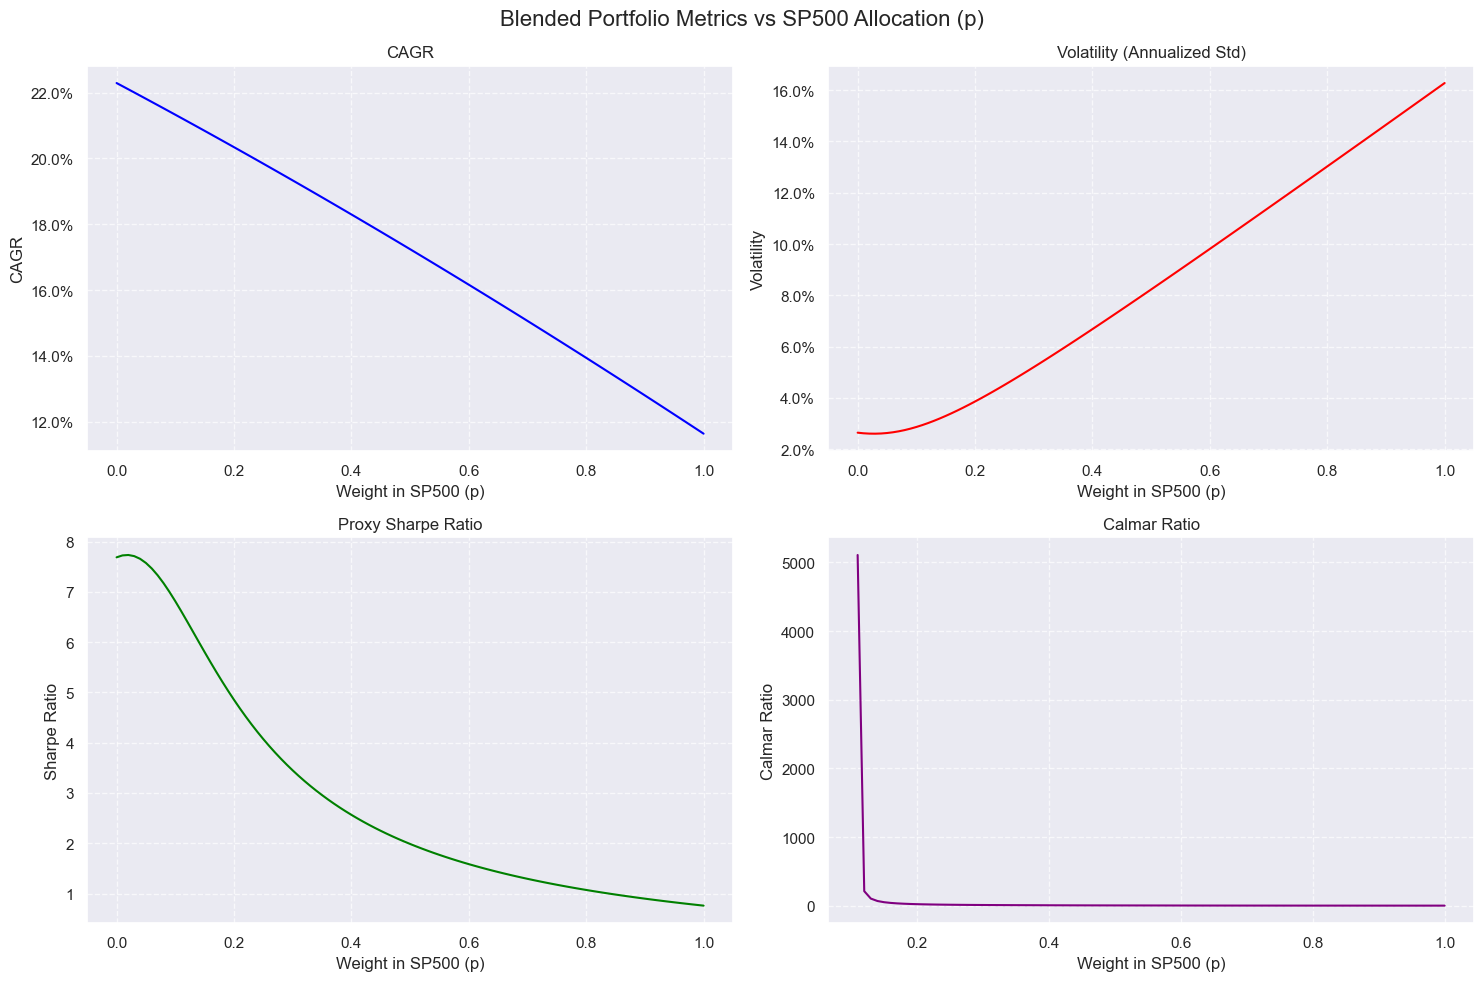

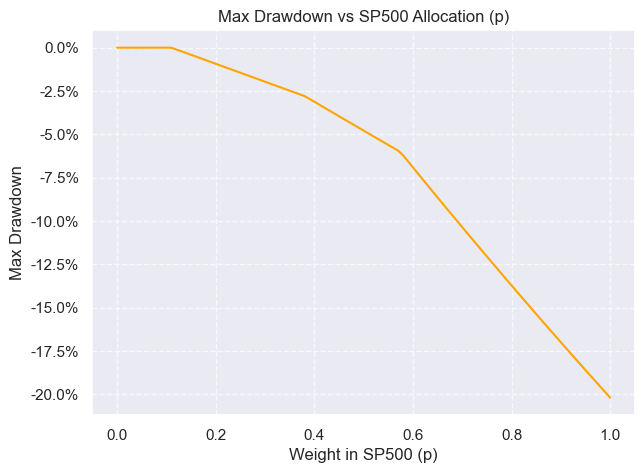

In [83]:
# --- Blended Portfolio Analysis (SP500 + Target Portfolio) ---
# p% in the SP500 and (1-p)% in the target portfolio (port_6m)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Align port_6m and sp500 exactly
common_idx = port_6m.dropna().index.intersection(sp500.dropna().index)
target_ret = port_6m.loc[common_idx]
sp500_ret = sp500.loc[common_idx]

p_values = np.linspace(0, 1, 101) # 0 to 100% in SP500
results = []

for p in p_values:
    # Portfolio return: p * SP500 + (1-p) * Target
    blend_ret = p * sp500_ret + (1 - p) * target_ret
    
    n_months = len(blend_ret)
    n_years = n_months / 12
    
    cum_wealth = (1 + blend_ret).cumprod()
    cagr = cum_wealth.iloc[-1]**(1/n_years) - 1 if cum_wealth.iloc[-1] > 0 else np.nan
    
    std = blend_ret.std() * np.sqrt(12)
    sharpe = (blend_ret.mean() * 12) / std if std != 0 else np.nan
    
    peak = cum_wealth.cummax()
    mdd = ((cum_wealth - peak) / peak).min()
    calmar = cagr / abs(mdd) if mdd != 0 else np.nan
    
    results.append({
        'p (SP500 Weight)': p,
        'CAGR': cagr,
        'Volatility': std,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': mdd,
        'Calmar Ratio': calmar
    })

blend_df = pd.DataFrame(results)

# Plotting the metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Blended Portfolio Metrics vs SP500 Allocation (p)', fontsize=16)

# CAGR
axes[0, 0].plot(blend_df['p (SP500 Weight)'], blend_df['CAGR'], color='blue')
axes[0, 0].set_title('CAGR')
axes[0, 0].set_xlabel('Weight in SP500 (p)')
axes[0, 0].set_ylabel('CAGR')
axes[0, 0].grid(True, linestyle='--', alpha=0.7)
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

# Volatility
axes[0, 1].plot(blend_df['p (SP500 Weight)'], blend_df['Volatility'], color='red')
axes[0, 1].set_title('Volatility (Annualized Std)')
axes[0, 1].set_xlabel('Weight in SP500 (p)')
axes[0, 1].set_ylabel('Volatility')
axes[0, 1].grid(True, linestyle='--', alpha=0.7)
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

# Sharpe Ratio
axes[1, 0].plot(blend_df['p (SP500 Weight)'], blend_df['Sharpe Ratio'], color='green')
axes[1, 0].set_title('Proxy Sharpe Ratio')
axes[1, 0].set_xlabel('Weight in SP500 (p)')
axes[1, 0].set_ylabel('Sharpe Ratio')
axes[1, 0].grid(True, linestyle='--', alpha=0.7)

# Calmar Ratio
axes[1, 1].plot(blend_df['p (SP500 Weight)'], blend_df['Calmar Ratio'], color='purple')
axes[1, 1].set_title('Calmar Ratio')
axes[1, 1].set_xlabel('Weight in SP500 (p)')
axes[1, 1].set_ylabel('Calmar Ratio')
axes[1, 1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Additional Plot: Max Drawdown
plt.figure(figsize=(7, 5))
plt.plot(blend_df['p (SP500 Weight)'], blend_df['Max Drawdown'], color='orange')
plt.title('Max Drawdown vs SP500 Allocation (p)')
plt.xlabel('Weight in SP500 (p)')
plt.ylabel('Max Drawdown')
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
plt.show()



In [84]:
import numpy as np
import pandas as pd

# Calculate CAGRs and Stds for each selected fund
cagrs = []
stds = []
funds_used = []
weights = []

# Using allocations_s which has the initial weights and df_funds which has the data
for f in allocations_s.index:
    if f in df_funds.columns:
        s = df_funds[f].dropna()
        if len(s) == 0:
            continue
        n_years = len(s) / 12
        cum_ret = (1 + s).prod()
        cagr = cum_ret**(1/n_years) - 1
        std = s.std() * np.sqrt(12)
        
        cagrs.append(cagr)
        stds.append(std)
        funds_used.append(f)
        weights.append(allocations_s[f])

cagrs = np.array(cagrs)
stds = np.array(stds)
weights = np.array(weights)

# Normalize weights
weights = weights / weights.sum()

# 1. Unweighted Calculations
mean_cagr = np.nanmean(cagrs)
mean_cagr_minus_1std = np.nanmean(cagrs - stds)
mean_cagr_minus_2std = np.nanmean(cagrs - 2 * stds)

print("--- Unweighted Metrics ---")
print(f"Mean of CAGRs: {mean_cagr:.2%}")
print(f"Mean of (CAGR - 1 Std): {mean_cagr_minus_1std:.2%}")
print(f"Mean of (CAGR - 2 Std): {mean_cagr_minus_2std:.2%}")

# 2. Weighted Calculations
weighted_mean_cagr = np.nansum(cagrs * weights)
weighted_mean_cagr_minus_1std = np.nansum((cagrs - stds) * weights)
weighted_mean_cagr_minus_2std = np.nansum((cagrs - 2 * stds) * weights)

print("\n--- Allocation Weighted Metrics ---")
print(f"Weighted Mean of CAGRs: {weighted_mean_cagr:.2%}")
print(f"Weighted Mean of (CAGR - 1 Std): {weighted_mean_cagr_minus_1std:.2%}")
print(f"Weighted Mean of (CAGR - 2 Std): {weighted_mean_cagr_minus_2std:.2%}")


--- Unweighted Metrics ---
Mean of CAGRs: 26.85%
Mean of (CAGR - 1 Std): 17.00%
Mean of (CAGR - 2 Std): 7.15%

--- Allocation Weighted Metrics ---
Weighted Mean of CAGRs: 28.56%
Weighted Mean of (CAGR - 1 Std): 19.08%
Weighted Mean of (CAGR - 2 Std): 9.59%


--- Monte Carlo Simulation Results (10000 runs) ---


Quantile,Pure Monte Carlo CAGR,3-Month Block Bootstrap CAGR
1%,18.95%,18.45%
5%,19.89%,19.50%
10%,20.40%,20.12%
25%,21.26%,21.19%
50%,22.29%,22.40%
75%,23.34%,23.69%
90%,24.28%,24.89%
95%,24.83%,25.62%
99%,25.93%,27.06%


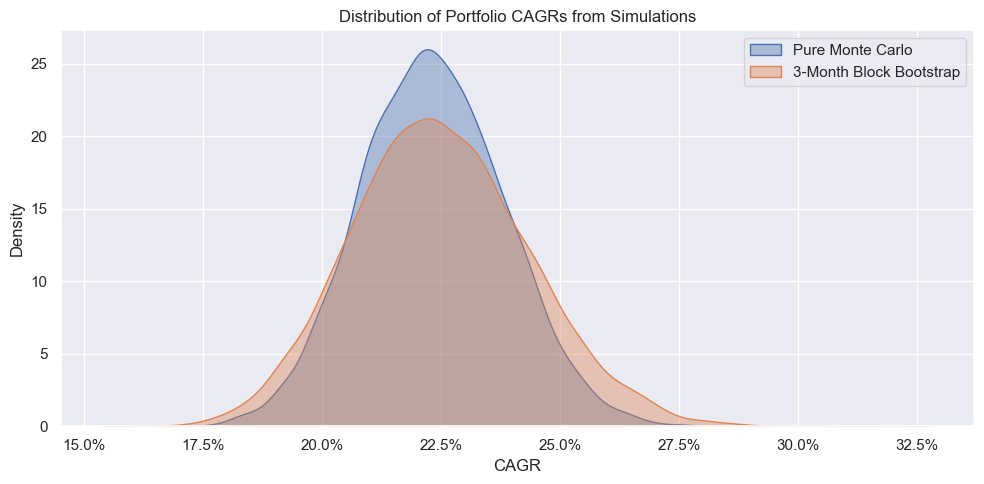

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Assuming the main portfolio returns are in '6-Month Reb Initial Alloc'
port_returns = all_portfolios_df['6-Month Reb Initial Alloc'].dropna()

n_simulations = 10000
n_months = len(port_returns)
n_years = n_months / 12

# 1. Pure Monte Carlo (Independent Sampling with Replacement)
mc_cagrs = []
for _ in range(n_simulations):
    simulated_returns = np.random.choice(port_returns, size=n_months, replace=True)
    cum_wealth = (1 + simulated_returns).prod()
    cagr = cum_wealth**(1/n_years) - 1
    mc_cagrs.append(cagr)

mc_cagrs = np.array(mc_cagrs)

# 2. Block Bootstrap (3-month blocks)
block_size = 3
n_blocks = int(np.ceil(n_months / block_size))

# Create blocks
blocks = [port_returns.iloc[i:i+block_size].values for i in range(0, n_months - block_size + 1)]

block_cagrs = []
for _ in range(n_simulations):
    # Sample blocks with replacement
    sampled_blocks_idx = np.random.randint(0, len(blocks), size=n_blocks)
    simulated_returns = np.concatenate([blocks[i] for i in sampled_blocks_idx])
    # Truncate to exact n_months if necessary
    simulated_returns = simulated_returns[:n_months]
    
    cum_wealth = (1 + simulated_returns).prod()
    cagr = cum_wealth**(1/n_years) - 1
    block_cagrs.append(cagr)

block_cagrs = np.array(block_cagrs)

# Calculate Quantiles
quantiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
mc_quantiles = np.quantile(mc_cagrs, quantiles)
block_quantiles = np.quantile(block_cagrs, quantiles)

results_df = pd.DataFrame({
    'Quantile': [f"{q*100:.0f}%" for q in quantiles],
    'Pure Monte Carlo CAGR': [f"{v:.2%}" for v in mc_quantiles],
    '3-Month Block Bootstrap CAGR': [f"{v:.2%}" for v in block_quantiles]
})

print(f"--- Monte Carlo Simulation Results ({n_simulations} runs) ---")
display(results_df.style.hide(axis="index"))

# Plotting the distributions
plt.figure(figsize=(10, 5))
sns.kdeplot(mc_cagrs, label='Pure Monte Carlo', fill=True, alpha=0.4)
sns.kdeplot(block_cagrs, label='3-Month Block Bootstrap', fill=True, alpha=0.4)
plt.title('Distribution of Portfolio CAGRs from Simulations')
plt.xlabel('CAGR')
plt.ylabel('Density')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
plt.legend()
plt.tight_layout()
plt.show()
